# Price-ending effects in language models — data collection


**The question.** Humans show a 99-cent effect because they misperceive magnitude.
Do language models show one for the same reason, or because they recognise a pricing
convention? These look identical under a standard vignette design and are separable
with placebos.

**The centrepiece.** A one-cent step from a 9-ending to a round ending happens ten times
inside every dollar, and only one of them crosses a dollar boundary:

```
.09→.10  .19→.20  .29→.30  .39→.40  .49→.50
.59→.60  .69→.70  .79→.80  .89→.90  .99→+1.00   ← the only dollar crossing
```

Nine placebos, one treatment. Left-digit bias requires the last step to stand alone.



## 0. Setup

```
pip install openai anthropic pandas numpy matplotlib pillow tiktoken tqdm
```
`anthropic` is only needed for E8 trace collection; everything else runs without it.

In [1]:
from __future__ import annotations

import base64, hashlib, io, json, math, os, random, re, sys, threading, time
from dataclasses import dataclass, field
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd

ROOT     = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA     = ROOT / "data"
TAGS     = DATA / "tags"          # rendered price-tag PNGs for the vision arm
TAGS.mkdir(parents=True, exist_ok=True)

PANELS = DATA / "panels"

def raw_dir(exp: str | None = None, mock: bool | None = None) -> Path:
    '''Where an arm's call log lives.

    Mock output is kept apart from real output so the two can never mix, and each
    experiment gets its own subdirectory so arms can be collected, inspected and
    re-run independently.
    '''
    d = DATA / ("raw_mock" if (MOCK if mock is None else mock) else "raw")
    if exp:
        d = d / exp
    d.mkdir(parents=True, exist_ok=True)
    return d

def panel_dir(mock: bool | None = None) -> Path:
    d = DATA / ("panels_mock" if (MOCK if mock is None else mock) else "panels")
    d.mkdir(parents=True, exist_ok=True)
    return d

try:
    import tiktoken
    _ENC = tiktoken.get_encoding("o200k_base")
    n_tokens = lambda t: len(_ENC.encode(t))
    TOKENISER = "tiktoken/o200k_base"
except Exception:
    n_tokens = lambda t: max(1, math.ceil(len(t) / 4))
    TOKENISER = "heuristic chars/4"

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **k: x

print("root      :", ROOT)
print("tokeniser :", TOKENISER)

root      : /Users/namanagrawal/Downloads/Random_Projects/left_digit_bias_llm
tokeniser : heuristic chars/4


## 1. The instrument: what can be collected, and where

This table decides the design. Verified against provider docs, August 2026.

| stack | logprobs | vision | raw CoT | role |
|---|---|---|---|---|
| `gpt-4.1` / `-mini` / `-nano` | yes (top 20) | **yes** | no | **primary instrument** |
| `gpt-4o` / `-mini` | yes | yes | no | older generation, tests drift |
| GPT-5.x, o-series | **no** | yes | summary | sampling fallback only |
| Claude | **no** | yes | **yes, raw** | E8 trace analysis only |
| Gemini (AI Studio) | **no** | yes | summary | excluded |
| open weights (vLLM/Together) | yes (full) | VL variants | n/a | scaling ladder |
| DeepSeek-R1, QwQ, Qwen3-thinking | yes | no | **yes** | reasoning + logprobs together |

Two consequences worth stating plainly:

1. **`gpt-4.1` gives logprobs *and* accepts images**, so the text-vs-vision contrast (E7)
   uses an identical instrument on the same model rather than being confounded by
   elicitation method.
2. **Claude cannot be measured precisely.** Use it only where raw thinking is the point.

In [2]:
# ---------------------------------------------------------------- model registry ----
# Prices are USD per 1M tokens, read from the OpenRouter models API (August 2026).
# `lp` is the decisive field and is taken from each model's supported_parameters:
# it decides whether a cell costs one call or twelve. Everything goes through one
# OpenRouter key.
@dataclass(frozen=True)
class Model:
    mid: str            # OpenRouter model id
    tier: str           # capability tier, for the scaling story
    inp: float          # usd / 1M input
    out: float          # usd / 1M output
    lp: bool = True     # exposes first-token logprobs
    img: bool = False   # accepts images
    rsn: bool = False   # reasoning model
    family: str = ""
    stack: str = "openrouter"   # which backend speaks to it
    note: str = ""

REGISTRY: dict[str, Model] = {m.mid: m for m in [
 # ===== TIER A: precision instrument. logprobs, so one call per cell. =====
 # OpenAI, logprobs AND vision: the only stack that measures text and image alike.
 Model("openai/gpt-4o",      "high", 2.50, 10.00, lp=True, img=True, family="gpt4o"),
 Model("openai/gpt-4o-mini", "low",  0.15,  0.60, lp=True, img=True, family="gpt4o"),
 # OpenAI open weights: logprobs AND reasoning, which the closed GPT-5.x models lack.
 # lp=False: verified live, this model returns no log-probabilities despite the
 # provider advertising them. Kept for the gpt-oss scaling pair, sampled, in E1 only.
 Model("openai/gpt-oss-120b","high", 0.037, 0.170, lp=False, rsn=True, family="gptoss"),
 Model("openai/gpt-oss-20b", "low",  0.030, 0.130, lp=True, rsn=True, family="gptoss"),
 # The controlled reasoning contrast: same base model, thinking off then on.
 Model("qwen/qwen3-235b-a22b-2507",          "high", 0.087, 0.350, lp=True, family="qwen3-235b"),
 # lp=False: a thinking model does not return log-probabilities on the answer token.
 # Kept because it is the reasoning half of the controlled pair, sampled, in E8 only.
 Model("qwen/qwen3-235b-a22b-thinking-2507", "high", 0.230, 2.300, lp=False, rsn=True,
       family="qwen3-235b", note="same base as the line above, thinking on"),
 # Qwen scaling ladder.
 Model("qwen/qwen3-30b-a3b-instruct-2507", "mid", 0.048, 0.193, lp=True, family="qwen3"),
 # lp=False verified live: these return no log-probabilities. Restored as sampled
 # because they fill out the Qwen scaling ladder in E1.
 Model("qwen/qwen3-32b",  "mid", 0.080, 0.280, lp=False, rsn=True, family="qwen3"),
 Model("qwen/qwen3-14b",  "mid", 0.120, 0.240, lp=False, rsn=True, family="qwen3"),
 Model("qwen/qwen3.5-9b", "low", 0.100, 0.150, lp=True, rsn=True, family="qwen3"),
 # DeepSeek, reasoning and non-reasoning, both with logprobs.
 Model("deepseek/deepseek-v4-flash",     "mid", 0.090, 0.180, lp=True, rsn=True, family="deepseek"),
 Model("deepseek/deepseek-chat-v3-0324", "mid", 0.250, 1.000, lp=True, family="deepseek"),
 # Vision + logprobs outside OpenAI: extra tokenizers and families for E7.
 Model("qwen/qwen3.7-flash",    "mid", 0.030, 0.130, lp=True, img=True, rsn=True, family="qwen3"),
 # lp=False: verified live. Kept as the only Google model that can be measured at all,
 # sampled, in E1 and E7.
 Model("google/gemma-3-27b-it", "mid", 0.080, 0.450, lp=False, img=True, family="gemma"),
 Model("google/gemma-4-31b-it", "mid", 0.090, 0.340, lp=False, img=True, rsn=True,
       family="gemma"),
 Model("mistralai/mistral-small-3.2-24b-instruct", "mid", 0.075, 0.200, lp=True, img=True,
       family="mistral"),

 # ===== TIER B: frontier. No logprobs, so sampled, and only on the MINI grid. =====
 # These are the newest models and the ones people will ask about. They cannot be
 # measured precisely: Claude exposes logprobs on none of its models, Gemini on none,
 # and the GPT-5.x line on none. They are here to show the headline survives, not to
 # carry the fine-grained analysis.
 Model("openai/gpt-5.6-sol",       "high", 2.00, 10.00, lp=False, img=True, rsn=True, family="gpt5"),
 Model("openai/gpt-5.6-luna",      "low",  0.20,  1.20, lp=False, img=True, rsn=True, family="gpt5"),
 Model("anthropic/claude-sonnet-5","high", 2.00, 10.00, lp=False, img=True, rsn=True, family="claude"),
]}

# ---- Gemini, through Google's own API rather than OpenRouter ----------------------
# The native API is the only place Gemini can even attempt log-probabilities
# (`responseLogprobs`), and support varies by model, so the backend probes once and
# falls back to sampling if it is refused.
REGISTRY.update({m.mid: m for m in [
 Model("gemini-3.7-flash",      "high", 0.75, 3.75, lp=False, img=True, rsn=True,
       family="gemini", stack="gemini"),
 Model("gemini-3.5-flash-lite", "low",  0.30, 2.50, lp=False, img=True, rsn=True,
       family="gemini", stack="gemini"),
]})

def M(mid: str) -> Model:
    if mid not in REGISTRY:
        raise KeyError(f"{mid} not in REGISTRY; add it with its OpenRouter price first")
    return REGISTRY[mid]

# Models that expose no log-probabilities but are kept anyway, each confined to the arm
# where it earns its 12-calls-per-cell price. Verified against the live pre-flight.
# Sampling costs twelve calls per cell, so each of these appears only in the arms where
# it earns that. All of them carry the model-coverage story in E1, which is the backbone;
# none of them are needed in the factorial arms, where five precision models already
# provide the contrast and per-cell precision actually matters.
SAMPLED_KEEP = {
    "openai/gpt-oss-120b":                {"E1"},        # scaling pair with gpt-oss-20b
    "qwen/qwen3-32b":                     {"E1"},        # Qwen ladder
    "qwen/qwen3-14b":                     {"E1"},        # Qwen ladder
    # E1 only, deliberately not E7. The whole point of the vision arm is comparing text
    # against images on the SAME model with the SAME read-out; a sampled model cannot do
    # that, because the instrument changes at the same time as the modality. Adding these
    # would buy two noisy extra rows at the cost of the comparison E7 exists to make.
    "google/gemma-3-27b-it":              {"E1"},        # Google family coverage
    "google/gemma-4-31b-it":              {"E1"},        # Google family coverage
    "qwen/qwen3-235b-a22b-thinking-2507": {"E8"},        # reasoning half of the pair
}
PRECISION = [m.mid for m in REGISTRY.values() if m.lp]
FRONTIER  = [m.mid for m in REGISTRY.values()
             if not m.lp and m.mid not in SAMPLED_KEEP]
by_stack = {}
for m in REGISTRY.values():
    by_stack.setdefault(m.stack, []).append(m.mid)
print(f"{len(REGISTRY)} models across {len(by_stack)} backends")
for k, v in by_stack.items():
    print(f"  {k:11s} {len(v):2d} models")
print(f"  Tier A precision (logprobs, 1 call/cell)  : {len(PRECISION)}")
print(f"  Tier B frontier  (sampled, no logprobs)   : {len(FRONTIER)}")
print(f"  vision + logprobs, usable for E7          : {sum(m.img and m.lp for m in REGISTRY.values())}")
print(f"  reasoning + logprobs, usable for E8       : {sum(m.rsn and m.lp for m in REGISTRY.values())}")


21 models across 2 backends
  openrouter  19 models
  gemini       2 models
  Tier A precision (logprobs, 1 call/cell)  : 10
  Tier B frontier  (sampled, no logprobs)   : 5
  vision + logprobs, usable for E7          : 4
  reasoning + logprobs, usable for E8       : 4


## 2. Configuration

In [3]:
# ---- money -------------------------------------------------------------------
# This is a LIFETIME cap, not a per-session one: realised spend is kept in
# data/spend.json and survives kernel restarts. The earlier in-memory version let
# spend reach 88 USD against a 44 USD cap across sessions without ever firing, and
# then fired in the middle of an arm the first time one session crossed it alone.
#
# Realised spend to date is about 88 USD (119 SGD). Finishing E7 on mistral and
# re-running E3 on the enlarged grid costs roughly 5 USD more, so this leaves
# headroom without being an open cheque. Raise it deliberately; do not raise it to
# get past an error.
BUDGET_SGD  = 130.00
USD_PER_SGD = 0.74
BUDGET_USD  = BUDGET_SGD * USD_PER_SGD

# ---- the grid ----------------------------------------------------------------
# For each decade d = 0..9 post .d0, .d5, .d9; then close the block with +1.00.
# 31 prices per dollar block: ten .d9 -> .(d+1)0 steps (nine placebos, one treatment)
# and 30 distinct endings for the E5 corpus regression.
DECADES      = list(range(10))
WITHIN       = [0, 5, 9]
CENT_OFFSETS = sorted({d * 10 + w for d in DECADES for w in WITHIN} | {100})

# E10 installs a fictional convention ("prices here conventionally end in .77") and asks
# whether the model's preference moves to that ending. That only tests anything if the
# ending is actually posted, so the installed endings join E10's grid. Without them the
# .77 and .33 arms announce a convention for a price the model is never offered.
INSTALLED_ENDINGS = [33, 77]
E10_OFFSETS = sorted(set(CENT_OFFSETS) | set(INSTALLED_ENDINGS))

N_ANCHORS    = 3      # dollar anchors per product
N_PERSONAS   = 5      # for the CORE grid

# E3 and E7 originally ran on the MINI grid and came out badly under-powered: about
# 60-100 informative blocks per condition against E1's 1,160, giving intervals ten
# times wider than the effect. They are also the two arms that discriminate the
# perceptual account from the semantic one, so they get their own larger grids.
E3_PRODUCTS, E3_ANCHORS, E3_PERSONAS = 8, 4, 9   # 1,440 blocks per domain
E7_PRODUCTS, E7_ANCHORS, E7_PERSONAS = 8, 4, 9   #   864 blocks per condition

# ---- elicitation --------------------------------------------------------------
TEMPERATURE    = 1.0    # keep at 1.0 so logprobs are the model's own distribution
MAX_OUT_TOKENS = 4      # one word, for non-reasoning models
# Reasoning tokens are billed and counted against max_tokens, so a reasoning model given
# a 4-token budget spends it thinking and returns an empty answer. It needs room.
MAX_OUT_REASONING = 1024
# For models that refuse to switch reasoning off, 1024 is still not enough: they spend it
# all thinking and return an empty answer. These get a far larger allowance.
MAX_OUT_THINKING  = 6144
MAX_OUT_COT    = 700    # reasoning arm needs room to think
SAMPLE_REPS    = 12     # for stacks without logprobs
OUT_BUDGETED   = 8      # conservative allowance in the projection

SEED        = 20260820
MAX_WORKERS = 40
MAX_RETRIES = 5

# Nothing here decides whether money is spent. Each run chunk further down carries its
# own SPEND flag, so you can see, at the cell you are about to execute, whether it will
# cost anything. This is only the default for anything that does not pass one.
MOCK = True

random.seed(SEED); np.random.seed(SEED % (2**32))
print(f"budget {BUDGET_SGD:.0f} SGD = {BUDGET_USD:.2f} USD | "
      f"MOCK={MOCK} ({'offline, free' if MOCK else 'LIVE, will spend'})")
print(f"{len(CENT_OFFSETS)} prices per dollar block: "
      f"{', '.join(('.%02d' % c) if c < 100 else '+1.00' for c in CENT_OFFSETS[:8])} ... ")

budget 130 SGD = 96.20 USD | MOCK=True (offline, free)
31 prices per dollar block: .00, .05, .09, .10, .15, .19, .20, .25 ... 


## 3. API keys

Put your keys in `api.txt` at the project root, one per line. Labelled or bare both
work, and bare keys are identified by prefix so the order does not matter:

```
sk-proj-...        # OpenAI
sk-or-v1-...       # OpenRouter
```

- **OpenRouter** reaches every model in the registry.
- **OpenAI**, if present, serves the `gpt-4o` family directly instead of going through
  OpenRouter. Optional: without it those two models simply route via OpenRouter.
- **Gemini** has no dedicated key here, so its models route through OpenRouter and are
  measured by sampling. They expose no log-probabilities on either path, so nothing is
  lost.

`api.txt` is gitignored. Missing keys disable their models rather than failing the run.


In [4]:
def load_keys(path: Path | None = None) -> dict[str, str]:
    """Read provider keys from api.txt.

    Accepts labelled lines (`OPENROUTER_API_KEY=...`) and bare keys one per line.
    Bare keys are identified by prefix, so the order they appear in does not matter:
    `sk-or-...` is OpenRouter, anything else beginning `sk-` is OpenAI.
    """
    keys: dict[str, str] = {}
    bare: list[str] = []
    path = path or (ROOT / "api.txt")
    if path.exists():
        raw = path.read_text().strip()
        if raw.startswith("{"):
            keys.update({k.upper(): v for k, v in json.loads(raw).items()})
        else:
            for line in raw.splitlines():
                line = line.strip()
                if not line or line.startswith("#"):
                    continue
                if "=" in line and not line.startswith("sk-"):
                    k, v = line.split("=", 1)
                    keys[k.strip().upper()] = v.strip().strip("\"'")
                else:
                    bare.append(line)
    for b in bare:                                  # identify unlabelled keys by prefix
        if b.startswith("sk-or"):
            keys.setdefault("OPENROUTER_API_KEY", b)
        elif b.startswith("AIza"):
            keys.setdefault("GEMINI_API_KEY", b)
        elif b.startswith("sk-"):
            keys.setdefault("OPENAI_API_KEY", b)
        else:                                       # unrecognised: fill the first gap
            for slot in ("OPENROUTER_API_KEY", "OPENAI_API_KEY", "GEMINI_API_KEY"):
                if slot not in keys:
                    keys[slot] = b
                    break
    for k in ("OPENROUTER_API_KEY", "OPENAI_API_KEY", "GEMINI_API_KEY", "GOOGLE_API_KEY"):
        if k not in keys and os.environ.get(k):
            keys[k] = os.environ[k]
    keys.setdefault("GEMINI_API_KEY", keys.get("GOOGLE_API_KEY", ""))
    return keys

KEYS = load_keys()
KEYS.setdefault("GEMINI_API_KEY", KEYS.get("GOOGLE_API_KEY", ""))
for prov in ("OPENROUTER", "OPENAI", "GEMINI"):
    k = KEYS.get(f"{prov}_API_KEY")
    print(f"  {prov:11s} {'ok  ' + k[:6] + '...' + k[-3:] if k else 'not set'}")
# Gemini has no key of its own here, so route it through OpenRouter instead. It has no
# log-probabilities either way, so nothing is lost beyond the (already absent) option of
# trying responseLogprobs.
if not KEYS.get("GEMINI_API_KEY"):
    # Re-key under the OpenRouter id, then drop the old entry. Writing to the old key
    # and deleting it would silently remove the models altogether.
    for mid, m in list(REGISTRY.items()):
        if m.stack == "gemini":
            new = f"google/{mid}"
            REGISTRY[new] = Model(new, m.tier, m.inp, m.out, lp=False, img=m.img,
                                  rsn=m.rsn, family=m.family, stack="openrouter")
            del REGISTRY[mid]
    print("  gemini: no dedicated key, routed via OpenRouter (sampled)")

# Use the OpenAI key directly for OpenAI-family models when it is present; otherwise
# they go through OpenRouter like everything else.
if KEYS.get("OPENAI_API_KEY"):
    for mid, m in list(REGISTRY.items()):
        if mid.startswith("openai/gpt-4o"):
            REGISTRY[mid] = Model(m.mid, m.tier, m.inp, m.out, lp=m.lp, img=m.img,
                                  rsn=m.rsn, family=m.family, stack="openai")
    print("  gpt-4o family: routed to the OpenAI API directly")

# Recomputed after the Gemini reroute. Must mirror the definition in the registry cell,
# including the SAMPLED_KEEP exclusion, or the demoted models leak into the frontier arm.
PRECISION = [m.mid for m in REGISTRY.values() if m.lp]
# E0 runs on every model that returns log-probabilities except gpt-4o, which measured
# $0.00044 per call against $0.00002 or less for the rest and would dominate the cost of
# an arm whose whole value is its block count.
E0_MODELS = [m for m in PRECISION if m != "openai/gpt-4o"]
E0B_MODELS = E0_MODELS
FRONTIER  = [m.mid for m in REGISTRY.values()
             if not m.lp and m.mid not in SAMPLED_KEEP]
print(f"  {len(PRECISION)} precision + {len(FRONTIER)} frontier models active")
if not KEYS:
    print("\n(no keys found; the mock backend below still runs the whole pipeline)")

  OPENROUTER  ok  sk-or-...1be
  OPENAI      ok  sk-pro...MgA
  GEMINI      not set
  gemini: no dedicated key, routed via OpenRouter (sampled)
  gpt-4o family: routed to the OpenAI API directly
  10 precision + 5 frontier models active


## 4. Materials: products and personas

Eight products spanning roughly \$5 to \$45, so the one-cent threshold is a very
different share of the price at each end. Five personas for the CORE grid, keeping the
careful/hurried contrast; personas are a **robustness axis, not a finding**.

In [5]:
@dataclass(frozen=True)
class Product:
    pid: str; name: str; descriptor: str; setting: str; ref: float

PRODUCTS = [
    Product("latte","a 12 oz latte","made to order, oat milk available",
            "you have stopped at a cafe on your way to work and you want a coffee",5.0),
    Product("sandwich","a chicken salad sandwich","made this morning, from the chiller",
            "it is one in the afternoon, you skipped breakfast, and you are at a food counter",7.0),
    Product("notebook","a hardcover A5 notebook","200 lined pages, elastic closure",
            "you are in a stationery shop and your current notebook is full",8.0),
    Product("cable","a 2 m braided USB-C charging cable","fast charging, one year warranty",
            "you are in an electronics shop and your old cable has stopped working",12.0),
    Product("pizza","a large takeaway pepperoni pizza","ready in fifteen minutes",
            "it is eight in the evening, you have not cooked, and you are hungry",16.0),
    Product("tshirt","a plain cotton crew-neck t-shirt","mid-weight, in your size",
            "you are in a clothing shop and you could use another plain t-shirt",18.0),
    Product("umbrella","a compact windproof umbrella","fits in a bag, automatic open",
            "rain has started, you are out without an umbrella, and you pass a shop",22.0),
    Product("headphones","a pair of wired in-ear headphones","in-line microphone, decent reviews",
            "your headphones broke this morning and you are in an electronics shop",27.0),
    Product("backpack","a 20 L everyday backpack","padded laptop sleeve, water resistant",
            "your current bag has a torn strap and you are passing a luggage shop",45.0),
]
PRODUCTS = PRODUCTS[:8]

# E0 needs prices with two and three dollar digits, because that is the only place where
# "the dollar figure changes" and "the leftmost digit changes" come apart. At $4.99 the
# two are the same event. At $12.99 -> $13.00 the dollar figure changes and the leftmost
# digit does not; at $19.99 -> $20.00 both change. Both land on .00, so everything that
# makes .00 attractive is common to the two and differences out.
E0_PRODUCTS = [
    Product("case","a shockproof phone case","raised bezel, in your phone's size",
            "you dropped your phone yesterday and you are in a phone accessory shop", 21.0),
    Product("lamp","an adjustable LED desk lamp","three brightness settings, USB port",
            "you are setting up a desk at home and the room light is too dim", 31.0),
    Product("daypack","a 20 L everyday backpack","padded laptop sleeve, water resistant",
            "your current bag has a torn strap and you are passing a luggage shop", 41.0),
    Product("speaker","a portable Bluetooth speaker","eight hour battery, splash resistant",
            "you are going away for the weekend and want music outdoors", 51.0),
    Product("kettle","a stainless steel electric kettle","1.7 litres, rapid boil",
            "your kettle stopped working this morning and you are in a homeware shop", 61.0),
    Product("keyboard","a compact mechanical keyboard","tactile switches, USB-C",
            "you type all day and your current keyboard is uncomfortable", 72.0),
    Product("shoes","a pair of everyday running shoes","neutral cushioning, in your size",
            "your running shoes are worn through and you are in a sports shop", 82.0),
    Product("jacket","an insulated winter jacket","water resistant shell, packable",
            "the cold has arrived and your old jacket no longer keeps you warm", 92.0),
]

# Anchors are chosen in matched pairs, so a block where the leftmost digit changes is
# compared with a block at almost the same price where it does not. Third element is a
# digit-count change, which is the strongest version of a leftmost-digit change.
#   pid          roll  same     roll top / same top
E0_PRODUCTS += [
    Product("wallet","a leather bifold wallet","card slots, coin pocket",
            "your wallet is falling apart and you are passing a leather goods shop", 21.0),
    Product("bottle","an insulated steel water bottle","750 ml, keeps drinks cold all day",
            "you are in an outdoors shop and you keep buying bottled water", 31.0),
    Product("board","a bamboo chopping board","large, with a juice groove",
            "you are in a homeware shop and your board is scarred and warped", 41.0),
    Product("mouse","a wireless ergonomic mouse","silent click, rechargeable",
            "your wrist aches after long days and you are in a computer shop", 51.0),
]

E0_PRODUCTS += [
    Product("mat","a large desk mat","stitched edge, non-slip base", 
            "you are tidying your desk and the surface is scratched", 61.0),
    Product("chair","a padded desk chair cushion","memory foam, washable cover",
            "you sit all day and your chair has gone flat", 72.0),
    Product("duffel","a 40 L weekend duffel bag","shoe compartment, shoulder strap",
            "you travel most months and your old bag has a broken zip", 82.0),
    Product("monitor","a 24 inch monitor stand with drawer","raises the screen, holds a keyboard",
            "your monitor is too low and your desk is cluttered", 92.0),
]

E0_ANCHORS = [("case",     19, 22),   # 19->20 changes 1 to 2 ; 22->23 leaves 2
               ("lamp",     29, 33),   # 29->30 ; 33->34
               ("daypack",  39, 43),   # 39->40 ; 43->44
               ("speaker",  49, 53),   # 49->50 ; 53->54
               ("kettle",   59, 63),   # 59->60 ; 63->64
               ("keyboard", 69, 74),   # 69->70 ; 74->75
               ("shoes",    79, 84),   # 79->80 ; 84->85
               ("jacket",   89, 94),   # 89->90 ; 94->95
               ("wallet",   19, 23),   # a second good at each of the lower decades, so
               ("bottle",   29, 34),   # that the contrast is not carried by one product
               ("board",    39, 44),
               ("mouse",    49, 54),
               ("mat",      59, 64),   # a second good at each of the upper decades too
               ("chair",    69, 73),
               ("duffel",   79, 83),
               ("monitor",  89, 93)]
# Digit-count changes, each paired with a same-leading-digit anchor at a similar level.
E0_WIDEN = [("cable", 9, 12), ("jacket", 99, 94)]

# E0 also carries the quarter-dollar endings. Their destinations sit between a plain
# multiple of ten and .50 in how often they are posted, which gives the roundness
# regression four measured levels instead of two.
E0_OFFSETS = sorted(set(CENT_OFFSETS) | {24, 25, 74, 75})
E0_PERSONAS = 9

# E0b. E0 leaves one thing bundled. In a two-digit price the leftmost digit can change only
# when the dollar figure crosses a ten, so the "leftmost changes" blocks also have the
# rounder destination. In base ten that bundling cannot be undone by choosing prices: a
# leftmost-digit change always lands on a round number at the leading scale.
#
# What can be varied is the POSITION of the crossing. In a three-digit price, crossing a ten
# may or may not involve the leftmost digit:
#
#   $214.99 -> $215.00   units digit changes, destination not a round ten      flat
#   $219.99 -> $220.00   tens digit changes, hundreds digit unchanged          inner
#   $199.99 -> $200.00   hundreds digit changes, and it is the leftmost        lead
#
# flat and inner differ only in the roundness of the destination, with no leftmost-digit
# change in either, so they measure the roundness gradient directly. lead adds the
# leftmost-digit change on top of one further roundness level. If the gradient measured
# between flat and inner accounts for lead, the effect is roundness; if lead falls below it,
# there is a leftmost-digit effect over and above roundness.
#
# The three anchors for a product sit within twenty dollars of each other, so the comparison
# is not between a $20 item and a $400 one.
E0B_PRODUCTS = [
    Product("bike","a commuter bicycle","seven gears, mudguards fitted",
            "your bicycle was stolen last week and you commute six miles each way", 210.0),
    Product("mattress","a memory foam mattress","medium firm, double size",
            "your mattress is a decade old and you wake up with a sore back", 215.0),
    Product("laptopbag","a leather laptop briefcase","fits a 16 inch machine, padded",
            "you start a new job on Monday and your old bag is falling apart", 310.0),
    Product("camera","a compact mirrorless camera","20 megapixels, kit lens included",
            "you are going travelling next month and want something better than a phone", 315.0),
    Product("suit","a wool two-piece suit","charcoal, off the peg, alterations included",
            "you have three interviews next month and no suit that fits", 410.0),
    Product("fridge","an under-counter fridge freezer","frost free, quiet running",
            "your fridge has stopped cooling and the repair quote was most of a new one", 415.0),
    Product("piano","a digital piano","88 weighted keys, stand included",
            "you are taking lessons again and the practice room is never free", 510.0),
    Product("ebike","an electric scooter","25 mile range, folds for storage",
            "your commute is four miles and the bus is unreliable", 515.0),
]

#   pid          flat  inner  lead     destinations: 215 / 220 / 200
E0B_ANCHORS = [("bike",      214, 219, 199),
               ("mattress",  214, 219, 199),
               ("laptopbag", 314, 319, 299),
               ("camera",    314, 319, 299),
               ("suit",      414, 419, 399),
               ("fridge",    414, 419, 399),
               ("piano",     514, 519, 499),
               ("ebike",     514, 519, 499)]
E0B_PERSONAS = 9

@dataclass(frozen=True)
class Persona:
    kid: str; label: str; deliberation: str; text: str

PERSONAS_ALL = [
    Persona("P1","student, careful","high",
            "You are a 21 year old university student living on a tight budget. You keep a "
            "spending log and you know roughly what things should cost."),
    Persona("P2","student, impulsive","low",
            "You are a 20 year old university student with very little spare money. You "
            "decide quickly and go with your gut rather than working things out."),
    Persona("P3","professional, deal-conscious","high",
            "You are a 38 year old professional with a comfortable salary who dislikes "
            "overpaying. You mentally compare the price against what you think it is worth."),
    Persona("P4","parent, distracted","low",
            "You are a 31 year old parent of a toddler on a moderate income. You are tired, "
            "distracted, and usually shopping in a hurry."),
    Persona("P5","retiree, careful","high",
            "You are a 68 year old retiree living on a fixed pension. You think carefully "
            "about every purchase and you notice prices."),
    # Added to give the E3 and E7 grids more blocks. Blocks scale linearly with personas,
    # so this is the cheapest available power, and persona remains a robustness axis
    # rather than a finding.
    Persona("P7","freelancer, irregular income","high",
            "You are a 29 year old freelancer whose income varies month to month. You keep "
            "a mental budget for each category of spending and you stick to it."),
    Persona("P8","senior manager, price-insensitive","low",
            "You are a 45 year old senior manager who earns a lot. You rarely pay much "
            "attention to the price of small purchases."),
    Persona("P9","schoolteacher, weighs value","high",
            "You are a 52 year old schoolteacher on a moderate salary. You weigh up whether "
            "something is worth the money before you buy it."),
    Persona("P10","gig worker, impulsive","low",
            "You are a 26 year old gig worker with irregular hours and irregular pay. You "
            "buy on impulse when something catches your eye."),
]
PERSONAS = PERSONAS_ALL[:N_PERSONAS]

# Special conditions used by E2 to test whether the persona is doing the work.
PERSONA_NONE = Persona("P0","no persona","none","")
PERSONA_LOAD = Persona("P6","student, impulsive, under time pressure","load",
    "You are a 20 year old university student with very little spare money. You decide "
    "quickly and go with your gut. You have ninety seconds before your bus leaves.")

PRODUCT_BY_ID = {p.pid: p for p in PRODUCTS + E0_PRODUCTS + E0B_PRODUCTS}
PERSONA_BY_ID = {p.kid: p for p in PERSONAS_ALL + [PERSONA_NONE, PERSONA_LOAD]}
print(f"{len(PRODUCTS)} products, {len(PERSONAS)} core personas (+P0 none, +P6 load)")

8 products, 5 core personas (+P0 none, +P6 load)


## 5. Prompts

Twelve templates. `T01` is the canonical one used by every experiment except E2, which
sweeps all twelve to report the **distribution** of the effect over the prompt space
rather than a point estimate.

Three invariants, asserted below:

1. every price renders with exactly two decimals, so `$13.00` and `$12.99` differ in the
   number and not in its shape;
2. no sale / discount / deal / offer / bargain wording anywhere, because a nine-ending
   can itself act as a discount cue and that is a different channel;
3. two prompts straddling a threshold differ in the digits and nothing else.

In [6]:
SYSTEM_CHOICE = (
    "You are role-playing one specific consumer making a real purchase decision in a shop. "
    "Decide the way that consumer would, given their circumstances and the price. "
    "Reply with exactly one word: YES if you buy it, NO if you do not. "
    "No explanation, no punctuation."
)

CANON = (
    "About you: {persona}\n\n"
    "Situation: {setting}.\n\n"
    "The item: {name}, {descriptor}.\n"
    "Price: {price}\n\n"
    "You have no coupon and you have not checked prices anywhere else today. "
    "If you do not buy it now, you go without it.\n\n"
    "Do you buy it at this price?"
)

# E2's prompt space. Varies register, order (price before/after the item), person,
# and whether the outside option is stated. The canonical template is T01.
TEMPLATES = {
"T01": CANON,
"T02": ("{persona}\n\n{setting}.\n\nYou are looking at {name} ({descriptor}) priced at "
        "{price}.\n\nDo you buy it?"),
"T03": ("Situation: {setting}.\nShopper: {persona}\nItem: {name}, {descriptor}\n"
        "Price: {price}\n\nDoes this shopper buy it?"),
"T04": ("Price: {price}\nItem: {name}, {descriptor}\nAbout you: {persona}\n"
        "Situation: {setting}.\n\nDo you buy it at this price?"),   # price first
"T05": ("{persona}\n\n{setting}. You see {name}, {descriptor}. The price is {price}. "
        "There is no coupon and you have not compared prices today. Buy it?"),
"T06": ("Consider a shopper: {persona}\n{setting}.\nThey see {name} "
        "({descriptor}) for {price}.\nWould they buy it?"),          # third person
"T07": ("You: {persona}\nWhere: {setting}\nWhat: {name}, {descriptor}\nHow much: {price}\n"
        "Buy?"),                                                     # terse
"T08": ("About you: {persona}\n\nSituation: {setting}.\n\nThe item: {name}, {descriptor}.\n"
        "Price: {price}\n\nDo you buy it at this price?"),           # no outside option
"T09": ("Imagine you are the following person. {persona} {setting}. In front of you is "
        "{name}, {descriptor}, marked {price}. Decide whether to buy it."),
"T10": ("[shopper] {persona}\n[context] {setting}\n[product] {name} — {descriptor}\n"
        "[price] {price}\n[question] purchase?"),                    # structured
"T11": ("{persona}\n\nToday: {setting}. The shop has {name} ({descriptor}) at {price}. "
        "If you pass on it you go without. What do you do?"),
"T12": ("You are shopping. {setting}. {persona}\n\n{name}, {descriptor} — {price}\n\n"
        "Buy it at this price?"),
}
CANON_ID = "T01"

def fmt_price(value: float, currency: str = "USD", unit: int = 1) -> str:
    '''Render a price. `unit` scales the grid: 1 = cents, 10 = dollars, 100 = tens.'''
    if currency == "JPY":                      # yen are conventionally whole numbers
        return f"¥{value * unit * 150:,.0f}"
    sym = {"USD": "$", "EUR": "€", "INR": "₹", "CHF": "CHF "}[currency]
    return f"{sym}{value * unit:,.2f}"

def build_choice_prompt(product_id, persona_id, price, *, template=CANON_ID,
                        currency="USD", unit=1, preamble="", rendering="plain",
                        price_text=None):
    p, per = PRODUCT_BY_ID[product_id], PERSONA_BY_ID[persona_id]
    if price_text is None:
        price_text = render_price_text(price, currency, unit, rendering)
    body = TEMPLATES[template].format(
        persona=per.text or "You are an ordinary shopper.",
        setting=p.setting, name=p.name, descriptor=p.descriptor, price=price_text)
    return [{"role": "system", "content": SYSTEM_CHOICE},
            {"role": "user",   "content": (preamble + "\n\n" if preamble else "") + body}]

def render_price_text(price, currency="USD", unit=1, rendering="plain"):
    '''E6 moves token boundaries while holding the number constant.'''
    base = fmt_price(price, currency, unit)
    if rendering == "plain":      return base
    if rendering == "spaced":     return base[0] + " " + base[1:]
    if rendering == "iso":        return f"USD {price * unit:,.2f}"
    if rendering == "words":      return f"{price * unit:,.2f} dollars"
    if rendering == "digitspace": return " ".join(base)
    raise ValueError(rendering)

a = build_choice_prompt("cable","P1",12.99)[1]["content"]
b = build_choice_prompt("cable","P1",13.00)[1]["content"]
print(a)
print("\n" + "-"*72)
print("chars differing across the threshold:", sum(x!=y for x,y in zip(a,b)),
      "| same length:", len(a)==len(b))
# No sale cue anywhere: a nine-ending can itself signal a discount, which is a
# different channel from misperception and would confound the whole design.
banned = ("sale","discount","deal","offer","bargain","cheap","reduced","special")
leaks = [(tid, w) for tid, t in TEMPLATES.items() for w in banned if w in t.lower()]
assert not leaks, f"sale cue leaked: {leaks}"
assert len(a) == len(b), "threshold prompts differ in length"
print("invariants hold across all", len(TEMPLATES), "templates")

About you: You are a 21 year old university student living on a tight budget. You keep a spending log and you know roughly what things should cost.

Situation: you are in an electronics shop and your old cable has stopped working.

The item: a 2 m braided USB-C charging cable, fast charging, one year warranty.
Price: $12.99

You have no coupon and you have not checked prices anywhere else today. If you do not buy it now, you go without it.

Do you buy it at this price?

------------------------------------------------------------------------
chars differing across the threshold: 3 | same length: True
invariants hold across all 12 templates


## 6. The price grids

**Decade grid** (E1 and most arms): 31 prices per dollar block.
**Scale ladder** (E1b): the same decade logic at `unit` = 1, 10, 100, so the digit that
changes at the step is the dollars, then the tens, then the hundreds. Human left-digit
bias is documented at all three; if the models' effect lives only in the cents field it
is about price endings, not leftmost digits.

In [7]:
def anchors(ref: float, n: int = N_ANCHORS) -> list[int]:
    '''n integer dollar anchors around ref, at least 2 apart so no price repeats.'''
    step = max(2, int(math.floor(0.18 * ref + 0.5)))
    return [int(math.floor(ref + (i - (n - 1) / 2) * step + 0.5)) for i in range(n)]

def block_prices(b: int, offsets=None) -> list[float]:
    return [round(b + c / 100.0, 2) for c in (offsets or CENT_OFFSETS)]

def ending_of(price: float) -> int:
    return int(round(100 * (price - math.floor(price + 1e-9)))) % 100

def decade_step(price: float) -> int | None:
    '''Which of the ten .d9 -> .(d+1)0 steps this price is the TOP of, else None.'''
    e = ending_of(price)
    if e == 0:   return 10          # a .00 price closes the .99 step
    if e % 10 == 0: return e // 10  # .10 closes .09, .20 closes .19, ...
    return None

def roundness(price: float) -> int:
    e = ending_of(price)
    if e == 0:  return 3
    if e == 50: return 2
    if e % 10 == 0: return 1
    return 0

for p in PRODUCTS[:3]:
    a = anchors(p.ref)
    g = [pr for b in a for pr in block_prices(b)]
    assert len(g) == len(set(g)) == N_ANCHORS * len(CENT_OFFSETS)
    print(f"{p.pid:11s} ref ${p.ref:5.2f}  anchors {a}  {len(g)} prices  "
          f"${min(g):.2f}–${max(g):.2f}")

demo = block_prices(12)
print("\none block:", ", ".join(f"{x:.2f}" for x in demo[:10]), "...")
print("decade steps in a block:",
      sorted({decade_step(x) for x in demo if decade_step(x)}))
print("distinct endings across a block:", len({ending_of(x) for x in demo}))

latte       ref $ 5.00  anchors [3, 5, 7]  93 prices  $3.00–$8.00
sandwich    ref $ 7.00  anchors [5, 7, 9]  93 prices  $5.00–$10.00
notebook    ref $ 8.00  anchors [6, 8, 10]  93 prices  $6.00–$11.00

one block: 12.00, 12.05, 12.09, 12.10, 12.15, 12.19, 12.20, 12.25, 12.29, 12.30 ...
decade steps in a block: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
distinct endings across a block: 30


## 7. Price-tag images (E7)

The vision arm. Real shelf tags set the cents smaller than the dollars, and that relative
size is itself a lever humans respond to. We render the same price at four cents sizes
plus a superscript variant, so "how perceptual is this?" becomes a dose-response question
rather than a binary one.

Tags are 512×512, which costs about 255 image tokens on the OpenAI vision models, and
each is cached to `data/tags/` keyed by its parameters so a rerun costs nothing.

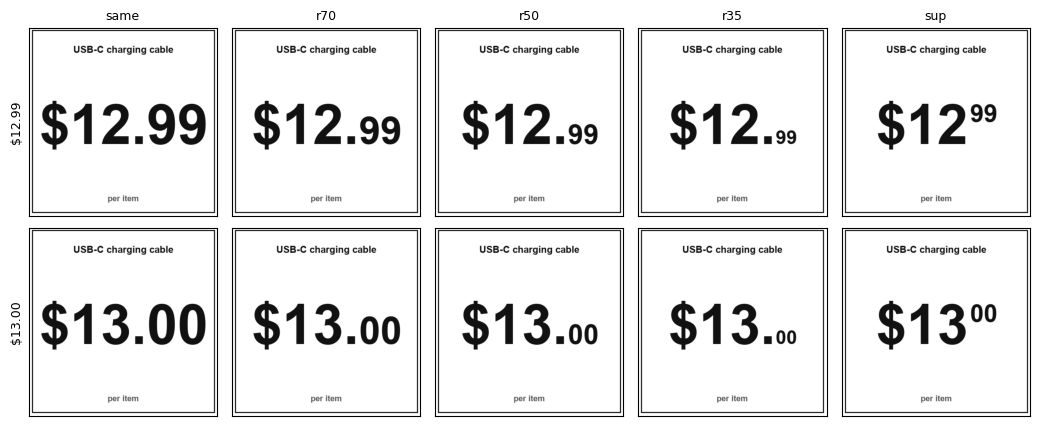

cents conditions: same, r70, r50, r35, sup


In [8]:
from PIL import Image, ImageDraw, ImageFont

FONT_CANDIDATES = [
    "/System/Library/Fonts/Supplemental/Arial Bold.ttf",
    "/System/Library/Fonts/Helvetica.ttc",
    "/Library/Fonts/Arial Bold.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
]
def _font(size: int):
    for p in FONT_CANDIDATES:
        if Path(p).exists():
            try:
                return ImageFont.truetype(p, size)
            except Exception:
                pass
    return ImageFont.load_default(size)

# The E7 factorial: how large the cents are relative to the dollar digits.
CENTS_CONDITIONS = {
    "same":  dict(ratio=1.00, sup=False),   # cents as large as dollars
    "r70":   dict(ratio=0.70, sup=False),
    "r50":   dict(ratio=0.50, sup=False),
    "r35":   dict(ratio=0.35, sup=False),   # the most aggressive shrink
    "sup":   dict(ratio=0.45, sup=True),    # superscript, as on many real tags
}

# E7 uses the size ladder plus the text control. "sup" is a different manipulation
# rather than a point on the ladder, so dropping it puts 20 percent more power into
# the dose-response the arm exists to measure.
E7_CONDITIONS = ["same", "r70", "r50", "r35"]

def render_price_tag(price: float, product_name: str, condition: str = "r50",
                     size: int = 512, currency: str = "USD") -> Image.Image:
    '''A plain shelf tag. Only the price rendering varies across conditions.'''
    cfg = CENTS_CONDITIONS[condition]
    img = Image.new("RGB", (size, size), "#FFFFFF")
    d = ImageDraw.Draw(img)
    d.rectangle([8, 8, size - 9, size - 9], outline="#111111", width=3)

    # product name, wrapped, at the top
    fname = _font(26)
    words, lines, cur = product_name.split(), [], ""
    for w in words:
        t = (cur + " " + w).strip()
        if d.textlength(t, font=fname) > size - 80:
            lines.append(cur); cur = w
        else:
            cur = t
    lines.append(cur)
    y = 46
    for ln in lines[:3]:
        d.text((size / 2, y), ln, font=fname, fill="#111111", anchor="ma")
        y += 32

    # the price: dollars big, cents scaled by the condition
    sym = {"USD": "$", "EUR": "€", "INR": "₹", "CHF": "CHF"}[currency]
    dollars = f"{sym}{int(math.floor(price + 1e-9)):,}"
    cents   = f"{ending_of(price):02d}"

    S = 150
    fbig   = _font(S)
    fsmall = _font(max(12, int(S * cfg["ratio"])))
    w_big  = d.textlength(dollars, font=fbig)
    w_dot  = 0 if cfg["sup"] else d.textlength(".", font=fbig)
    w_sml  = d.textlength(cents, font=fsmall)
    total  = w_big + w_dot + w_sml + (6 if cfg["sup"] else 0)

    x0 = (size - total) / 2
    baseline = size * 0.62
    d.text((x0, baseline), dollars, font=fbig, fill="#111111", anchor="ls")
    x = x0 + w_big
    if not cfg["sup"]:
        d.text((x, baseline), ".", font=fbig, fill="#111111", anchor="ls")
        x += w_dot
        d.text((x, baseline), cents, font=fsmall, fill="#111111", anchor="ls")
    else:
        # superscript: cents ride at the top of the dollar digits
        top = baseline - S * 0.72
        d.text((x + 6, top), cents, font=fsmall, fill="#111111", anchor="lt")

    d.text((size / 2, size - 40), "per item", font=_font(22),
           fill="#555555", anchor="ms")
    return img

def tag_path(price, product_name, condition, currency="USD") -> Path:
    h = hashlib.md5(f"{price}|{product_name}|{condition}|{currency}".encode()).hexdigest()[:12]
    return TAGS / f"tag_{h}.png"

def get_tag(price, product_name, condition, currency="USD") -> Path:
    p = tag_path(price, product_name, condition, currency)
    if not p.exists():
        render_price_tag(price, product_name, condition, currency=currency).save(p)
    return p

def tag_data_url(path: Path) -> str:
    return "data:image/png;base64," + base64.b64encode(path.read_bytes()).decode()

# Render the five conditions at the threshold pair and show them.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, len(CENTS_CONDITIONS),
                         figsize=(2.1 * len(CENTS_CONDITIONS), 4.4))
for j, cond in enumerate(CENTS_CONDITIONS):
    for i, pr in enumerate([12.99, 13.00]):
        ax = axes[i, j]
        ax.imshow(render_price_tag(pr, "USB-C charging cable", cond))
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0: ax.set_title(cond, fontsize=9)
        if j == 0: ax.set_ylabel(f"${pr:.2f}", fontsize=9)
plt.tight_layout(); plt.show()
print("cents conditions:", ", ".join(CENTS_CONDITIONS))

## 8. Manifests

Every experiment emits rows in one schema, so one runner and one cost guard serve all
ten. `experiment` and `mode` decide how each row is dispatched.

In [9]:
def _row(**kw) -> dict:
    base = dict(experiment="", model="", mode="logprob", rep=0,
                product="", ref_price=0.0, anchor=0, unit=1, price=0.0,
                currency="USD", rendering="plain", template=CANON_ID,
                persona="P1", deliberation="", preamble_id="none", preamble="",
                cents_cond="", domain="price", probe="")
    base.update(kw)
    e = ending_of(base["price"])
    base.update(ending=e, decade_step=decade_step(base["price"]),
                crosses_dollar=int(e == 0 and base["price"] > 0),
                roundness=roundness(base["price"]),
                dollars=int(math.floor(base["price"] + 1e-9)))
    # Every field that distinguishes a condition must appear here, or two different
    # conditions collide onto one call_id and the resume logic silently drops one.
    key = "|".join(str(base[k]) for k in
                   ("experiment","model","product","persona","template","currency",
                    "rendering","cents_cond","domain","unit","probe","preamble_id"))
    base["call_id"] = f"{key}|{int(round(base['price']*100))}"
    # Mask to 31 bits. Google declares generation_config.seed as a signed int32 and
    # rejects anything above 2**31-1, which is half of all 32-bit values: exactly the
    # 50 percent failure rate both Gemini models showed in E1f.
    base["seed"] = int(hashlib.md5(f"{base['call_id']}|{base['rep']}|{SEED}"
                                   .encode()).hexdigest()[:8], 16) & 0x7FFFFFFF
    return base

def grid(products, n_anchors=N_ANCHORS, personas=None, offsets=None, **kw):
    personas = personas or [p.kid for p in PERSONAS]
    out = []
    for prod in products:
        for b in anchors(prod.ref, n_anchors):
            for price in block_prices(b, offsets):
                for kid in personas:
                    out.append(_row(product=prod.pid, ref_price=prod.ref, anchor=b,
                                    price=price, persona=kid,
                                    deliberation=PERSONA_BY_ID[kid].deliberation, **kw))
    return out

CORE = PRODUCTS                 # 8 products
MINI = PRODUCTS[:4]             # 4 products for the factorial arms
MINI_PERS = ["P1", "P2", "P5"]

# Which models each arm runs on. Tier A carries every fine-grained analysis; Tier B
# only has to show the headline survives on the newest models, so it gets MINI.
def sampled_for(arm): return [m for m, arms in SAMPLED_KEEP.items() if arm in arms]

E1_MODELS = [m for m in PRECISION] + sampled_for("E1")
# gpt-4o is 91 percent of the vision arm's per-cell cost: images are token-heavy and
# it is priced at $2.50/$10 per 1M. Including it buys about 2.7x less power per dollar
# than spending the same money on the other vision models, so E7 uses gpt-4o-mini as
# the OpenAI representative: same family and tokenizer, vision and log-probabilities,
# one seventeenth of the cost.
VLM_SET   = [m for m in PRECISION if M(m).img and m != "openai/gpt-4o"]
# gpt-4o is by far the most expensive model here, so it runs on E1 and E7, where the
# high tier and the vision instrument matter, and gpt-4o-mini stands in on the
# factorial arms. That roughly halves the total spend.
# Five models for the factorial arms, one per family, all confirmed to return
# log-probabilities in the live pre-flight.
SMALL_SET = ["openai/gpt-4o-mini",
             "qwen/qwen3-235b-a22b-2507",
             "qwen/qwen3-30b-a3b-instruct-2507",
             "deepseek/deepseek-v4-flash",
             "mistralai/mistral-small-3.2-24b-instruct"]
COT_SET   = ["qwen/qwen3-235b-a22b-2507", "qwen/qwen3-235b-a22b-thinking-2507",
             "openai/gpt-oss-20b",
             "deepseek/deepseek-v4-flash", "deepseek/deepseek-chat-v3-0324"]
assert all(m in REGISTRY for m in E1_MODELS + VLM_SET + SMALL_SET + COT_SET)
print(f"E1 {len(E1_MODELS)} | VLM {len(VLM_SET)} | small {len(SMALL_SET)} "
      f"| CoT {len(COT_SET)} | frontier {len(FRONTIER)}")

def build(exp: str) -> list[dict]:
    R = []
    if exp == "E1":            # ending-shaped or threshold-shaped?
        for m in E1_MODELS:
            R += grid(CORE, model=m, experiment="E1")
    elif exp == "E1f":         # frontier check: no logprobs, so sampled, MINI grid
        for m in FRONTIER:
            R += grid(MINI, 2, MINI_PERS, model=m, experiment="E1f", mode="sample")
    elif exp == "E1b":         # scale ladder: cents vs tens vs hundreds
        for m in SMALL_SET:
            for unit in (10, 100):
                R += grid(MINI, 2, MINI_PERS, model=m, experiment="E1b", unit=unit)
    elif exp == "E2":          # prompt space
        for m in SMALL_SET[:5]:
            for t in TEMPLATES:
                for kid in ["P0", "P2", "P6"]:
                    R += grid(MINI, 2, [kid], model=m, experiment="E2", template=t)
    elif exp == "E3":          # prices or numbers?
        for m in SMALL_SET:
            for dom in ("odometer","calories","weight","delivery_days","rating"):
                R += grid(PRODUCTS[:E3_PRODUCTS], E3_ANCHORS,
                          [p.kid for p in PERSONAS_ALL[:E3_PERSONAS]],
                          model=m, experiment="E3", domain=dom)
    elif exp == "E4":          # locale and convention
        for m in SMALL_SET:
            for cur in ("USD","EUR","INR","JPY","CHF"):
                R += grid(MINI, 2, MINI_PERS, model=m, experiment="E4", currency=cur)
    elif exp == "E6":          # tokenization
        for m in SMALL_SET[:4]:
            for r in ("plain","spaced","iso","words","digitspace"):
                R += grid(MINI, 2, MINI_PERS, model=m, experiment="E6", rendering=r)
    elif exp == "E7":          # vision
        for m in VLM_SET:
            pers = [p.kid for p in PERSONAS_ALL[:E7_PERSONAS]]
            for cond in E7_CONDITIONS + ["textonly"]:
                R += grid(PRODUCTS[:E7_PRODUCTS], E7_ANCHORS, pers,
                          model=m, experiment="E7", cents_cond=cond, mode="logprob")
    elif exp == "E8":          # reasoning and traces
        for m in COT_SET:
            R += grid(MINI[:2], 1, MINI_PERS, model=m, experiment="E8",
                      mode="logprob_after_cot")
    elif exp == "E9":          # do they know the arithmetic?
        for m in E1_MODELS:
            for prod in MINI[:1]:
                for b in anchors(prod.ref, 2):
                    for price in block_prices(b):
                        for probe in ("compare","magnitude"):
                            R.append(_row(experiment="E9", model=m, probe=probe,
                                          product=prod.pid, ref_price=prod.ref,
                                          anchor=b, price=price, persona="P0"))
    elif exp == "E10":         # can the convention be installed in context?
        PRE = {"none":"", 
               "p77":"In Ruritania, retail prices conventionally end in .77. Shoppers "
                     "there are used to seeing prices like 4.77 and 12.77.",
               "p33":"In Ruritania, retail prices conventionally end in .33. Shoppers "
                     "there are used to seeing prices like 4.33 and 12.33.",
               "p00":"In Ruritania, retail prices are conventionally whole numbers. "
                     "Shoppers there are used to seeing prices like 4.00 and 12.00."}
        for m in SMALL_SET:
            for pid, txt in PRE.items():
                R += grid(MINI, 2, MINI_PERS, model=m, experiment="E10",
                          offsets=E10_OFFSETS, preamble_id=pid, preamble=txt)
    elif exp == "E0b":         # is it the leftmost digit, or the roundness it implies?
        pers = [p.kid for p in PERSONAS_ALL[:E0B_PERSONAS]]
        for m in E0B_MODELS:
            for pid, *ancs in E0B_ANCHORS:
                prod = PRODUCT_BY_ID[pid]
                for b in ancs:
                    for price in block_prices(b, E0_OFFSETS):
                        for kid in pers:
                            R.append(_row(product=prod.pid, ref_price=prod.ref, anchor=b,
                                          price=price, persona=kid,
                                          deliberation=PERSONA_BY_ID[kid].deliberation,
                                          model=m, experiment="E0b"))
    elif exp == "E0":          # does the effect need the leftmost digit to change?
        pairs, seen = [], set()
        for pid, a, b in E0_ANCHORS + E0_WIDEN:
            for anc in (a, b):
                if (pid, anc) not in seen:
                    seen.add((pid, anc)); pairs.append((pid, anc))
        pers = [p.kid for p in PERSONAS_ALL[:E0_PERSONAS]]
        for m in E0_MODELS:
            for pid, b in pairs:
                prod = PRODUCT_BY_ID[pid]
                for price in block_prices(b, E0_OFFSETS):
                    for kid in pers:
                        R.append(_row(product=prod.pid, ref_price=prod.ref, anchor=b,
                                      price=price, persona=kid,
                                      deliberation=PERSONA_BY_ID[kid].deliberation,
                                      model=m, experiment="E0"))
    else:
        raise ValueError(exp)
    return R

EXPERIMENTS = ["E1","E1f","E1b","E2","E3","E4","E6","E7","E8","E9","E10","E0","E0b"]
MANIFEST = pd.DataFrame([r for e in EXPERIMENTS for r in build(e)])
dups = MANIFEST[MANIFEST.duplicated(subset=["call_id","rep"], keep=False)]
assert dups.empty, (f"{len(dups)} colliding cells, e.g.\n"
                    f"{dups.head(4)[['experiment','model','preamble_id','price']]}")
print(MANIFEST.groupby("experiment", sort=False)
      .agg(calls=("call_id","size"), models=("model","nunique"))
      .assign(pct=lambda d: (100*d.calls/d.calls.sum()).round(1)).to_string())
print(f"\nTOTAL {len(MANIFEST):,} calls")

E1 15 | VLM 3 | small 5 | CoT 5 | frontier 5
             calls  models   pct
experiment                      
E1           55800      15   8.2
E1f           3720       5   0.5
E1b           7440       5   1.1
E2           44640       5   6.6
E3          223200       5  32.9
E4           18600       5   2.7
E6           14880       4   2.2
E7          133920       3  19.7
E8             930       5   0.1
E9            1860      15   0.3
E10          15840       5   2.3
E0           93555       9  13.8
E0b          64152       9   9.5

TOTAL 678,537 calls


## 9. Prompt dispatch

One entry point, `build_messages(row)`, routes each manifest row to the right prompt:
the canonical choice prompt, an image-tag prompt for E7, a non-price magnitude for E3,
or an arithmetic probe for E9. The cost projection below measures real prompts through
this function, so the estimate reflects what will actually be sent.

In [10]:
# ------------------------------------------------------- E9 arithmetic probes ----
SYSTEM_PROBE = "Answer with exactly one word and nothing else."

def build_probe_prompt(row) -> list[dict]:
    '''E9: can the model do the comparison it is supposedly getting wrong?'''
    lo = row["price"]
    hi = round(lo + 0.01, 2)
    if row["probe"] == "compare":
        q = (f"Which price is lower, {fmt_price(lo)} or {fmt_price(hi)}? "
             f"Answer with exactly one word: FIRST or SECOND.")
    else:
        q = (f"How much more expensive is {fmt_price(hi)} than {fmt_price(lo)}? "
             f"Answer with a single number, in cents.")
    return [{"role":"system","content":SYSTEM_PROBE},{"role":"user","content":q}]

def images_for(row) -> tuple:
    if row["experiment"] != "E7" or row["cents_cond"] in ("", "textonly"):
        return ()
    p = get_tag(row["price"], PRODUCT_BY_ID[row["product"]].name,
                row["cents_cond"], row["currency"])
    return (tag_data_url(p),)

def build_messages(row) -> list[dict]:
    if row["experiment"] == "E9":
        return build_probe_prompt(row)
    if row["experiment"] == "E7" and row["cents_cond"] not in ("", "textonly"):
        p = PRODUCT_BY_ID[row["product"]]; per = PERSONA_BY_ID[row["persona"]]
        body = (f"About you: {per.text}\n\nSituation: {p.setting}.\n\n"
                f"The item: {p.name}, {p.descriptor}.\n"
                f"The price is shown on the tag in the image.\n\n"
                f"You have no coupon and you have not checked prices anywhere else "
                f"today. If you do not buy it now, you go without it.\n\n"
                f"Do you buy it at this price?")
        return [{"role":"system","content":SYSTEM_CHOICE},{"role":"user","content":body}]
    if row["experiment"] == "E3":
        return build_domain_prompt(row)
    return build_choice_prompt(row["product"], row["persona"], row["price"],
                               template=row["template"], currency=row["currency"],
                               unit=row["unit"], preamble=row["preamble"],
                               rendering=row["rendering"])

DOMAINS = {
 "odometer":     ("a used hatchback, five years old, one owner",
                  "the odometer reads {v} miles", "Would you consider this car?"),
 "calories":     ("a supermarket ready meal",
                  "the label says {v} calories per portion", "Would you eat this?"),
 "weight":       ("a bag of rice", "the pack weighs {v} kg", "Would you buy this pack?"),
 "delivery_days":("an online order", "delivery takes {v} days", "Would you place the order?"),
 "rating":       ("a restaurant", "its average rating is {v} out of 10",
                  "Would you eat there?"),
}
DOMAIN_SCALE = {"odometer": 10000, "calories": 100, "weight": 1,
                "delivery_days": 1, "rating": 1}

def build_domain_prompt(row) -> list[dict]:
    '''E3: the same decade structure on magnitudes that are not retail prices.'''
    thing, fact, ask = DOMAINS[row["domain"]]
    v = row["price"] * DOMAIN_SCALE[row["domain"]]
    v_txt = f"{v:,.0f}" if DOMAIN_SCALE[row["domain"]] > 1 else f"{v:,.2f}"
    per = PERSONA_BY_ID[row["persona"]]
    body = (f"About you: {per.text or 'You are an ordinary person.'}\n\n"
            f"You are considering {thing}, and {fact.format(v=v_txt)}.\n\n{ask}\n"
            f"Reply with exactly one word: YES or NO.")
    return [{"role":"system","content":SYSTEM_CHOICE},{"role":"user","content":body}]

print("prompt dispatch ready for:", ", ".join(EXPERIMENTS))
print("\nE9 probe example:\n ", build_probe_prompt({"price":12.99,"probe":"compare"})[1]["content"])
print("\nE3 domain example:\n ", build_domain_prompt(
    {"domain":"odometer","price":7.99,"persona":"P1"})[1]["content"][:190], "...")

prompt dispatch ready for: E1, E1f, E1b, E2, E3, E4, E6, E7, E8, E9, E10, E0, E0b

E9 probe example:
  Which price is lower, $12.99 or $13.00? Answer with exactly one word: FIRST or SECOND.

E3 domain example:
  About you: You are a 21 year old university student living on a tight budget. You keep a spending log and you know roughly what things should cost.

You are considering a used hatchback, fiv ...


## 10. Cost projection

Priced from the registry, using measured input-token counts. A 512×512 tag costs
`85 + 170 = 255` image tokens on the OpenAI vision models. The cell refuses to continue
if the projection exceeds the budget.

In [11]:
IMAGE_TOKENS = 255          # 512x512: 85 base + 170 for one tile
SAMPLE_EXPS  = set()        # experiments forced into sampling mode (none by default)

def out_budget(row) -> int:
    if row["mode"] == "logprob_after_cot":
        return MAX_OUT_COT
    return OUT_BUDGETED

def measure_inputs(man: pd.DataFrame) -> pd.Series:
    '''Mean input tokens per (experiment, model), measured on a sample of real prompts.'''
    vals = {}
    for (exp, mid), g in man.groupby(["experiment","model"], sort=False):
        s = g.drop_duplicates(subset=["product","persona","template"]).head(12)
        tot = 0
        for _, r in s.iterrows():
            if r["experiment"] == "E9":
                msgs = build_probe_prompt(r)
            else:
                msgs = build_choice_prompt(
                    r["product"], r["persona"], r["price"], template=r["template"],
                    currency=r["currency"], unit=r["unit"], preamble=r["preamble"],
                    rendering=r["rendering"])
            tot += sum(n_tokens(m["content"]) for m in msgs)
        base = tot / max(len(s), 1)
        if r["experiment"] == "E7" and r["cents_cond"] != "textonly":
            base += IMAGE_TOKENS
        vals[(exp, mid)] = base
    return pd.Series(vals)

def project(man: pd.DataFrame) -> pd.DataFrame:
    inputs = measure_inputs(man)
    rows = []
    for (exp, mid), g in man.groupby(["experiment","model"], sort=False):
        m = M(mid)
        reps = SAMPLE_REPS if (not m.lp or exp in SAMPLE_EXPS) else 1
        n = len(g) * reps
        i_tok = inputs[(exp, mid)]
        o_tok = out_budget(g.iloc[0])
        usd = n * (i_tok * m.inp + o_tok * m.out) / 1e6
        rows.append(dict(experiment=exp, model=mid, calls=n,
                         in_tok=round(i_tok), out_tok=o_tok, usd=usd))
    df = pd.DataFrame(rows)
    return df

COST = project(MANIFEST)
by_exp = (COST.groupby("experiment", sort=False)
              .agg(calls=("calls","sum"), usd=("usd","sum")))
by_exp["sgd"] = by_exp.usd / USD_PER_SGD
by_exp.loc["TOTAL"] = by_exp.sum()
print(by_exp.round(2).to_string())

TOTAL_USD = float(by_exp.loc["TOTAL","usd"])
print(f"\nprojected {TOTAL_USD:,.2f} USD = {TOTAL_USD/USD_PER_SGD:,.2f} SGD "
      f"({TOTAL_USD/BUDGET_USD:.0%} of the {BUDGET_SGD:.0f} SGD budget)")
print("\nmost expensive models:")
print(COST.groupby("model").usd.sum().sort_values(ascending=False).head(6).round(2).to_string())
assert TOTAL_USD <= BUDGET_USD, (
    f"projection {TOTAL_USD:.2f} USD over the {BUDGET_USD:.2f} USD cap: "
    f"drop models from E1_MODELS or reduce N_ANCHORS")
print("\nwithin budget")

               calls    usd    sgd
experiment                        
E1          260400.0   6.45   8.72
E1f          44640.0  10.42  14.08
E1b           7440.0   0.14   0.19
E2           44640.0   0.81   1.10
E3          223200.0   4.14   5.60
E4           18600.0   0.35   0.47
E6           14880.0   0.29   0.39
E7          133920.0   5.28   7.13
E8            2976.0   3.92   5.29
E9            8680.0   0.06   0.09
E10          15840.0   0.30   0.40
E0           93555.0   1.86   2.52
E0b          64152.0   1.26   1.70
TOTAL       932923.0  35.28  47.67

projected 35.28 USD = 47.67 SGD (37% of the 130 SGD budget)

most expensive models:
model
openai/gpt-4o-mini                          5.88
anthropic/claude-sonnet-5                   3.94
openai/gpt-5.6-sol                          3.94
qwen/qwen3-235b-a22b-thinking-2507          3.69
mistralai/mistral-small-3.2-24b-instruct    2.78
openai/gpt-4o                               2.00

within budget


## 11. Backends and the spend guard

Three backends behind one interface. `MockBackend` generates data from a known
data-generating process so the whole pipeline — manifests, prompts, collection,
aggregation, analysis — can be exercised without spending anything.

In [12]:
class BudgetExceeded(RuntimeError): pass

LEDGER = DATA / "spend.json"

def ledger_from_logs() -> float:
    """Realised spend recomputed from the call logs. The audit trail, not the ledger."""
    total = 0.0
    for f in (DATA / "raw").glob("*/*.jsonl"):
        with open(f) as fh:
            for line in fh:
                try: total += float(json.loads(line).get("cost_usd") or 0.0)
                except Exception: continue
    return total

class Budget:
    '''Realised spend, charged from usage blocks and persisted across kernel sessions.

    The total used to live in memory only, so the cap was enforced within one kernel
    and forgotten on every restart. Realised spend reached 88 USD against a 44 USD cap
    without the guard ever firing, and then fired mid-arm the first time a single
    session crossed it on its own.
    '''
    def __init__(self, cap, path=LEDGER):
        self.cap, self.path, self.n = cap, path, 0
        self.session, self.prior, self._written = 0.0, 0.0, 0.0
        self._l = threading.Lock()
        if path is not None and path.exists():
            try: self.prior = float(json.loads(path.read_text()).get("usd", 0.0))
            except Exception: self.prior = 0.0

    @property
    def usd(self): return self.prior + self.session

    def _persist(self):
        if self.path is None: return
        self.path.write_text(json.dumps(
            {"usd": round(self.usd, 6), "ts": time.strftime("%Y-%m-%dT%H:%M:%S")}))
        self._written = time.time()

    def charge(self, mid, n_in, n_out):
        m = M(mid); c = (n_in * m.inp + n_out * m.out) / 1e6
        with self._l:
            self.session += c; self.n += 1
            over = self.usd > self.cap
            # Persisting on every call would be 40,000 small writes an arm; every two
            # seconds loses at most two seconds of spend to a hard kill, and the cap
            # crossing itself is always written.
            if over or time.time() - self._written > 2.0:
                self._persist()
            if over:
                raise BudgetExceeded(
                    f"realised {self.usd:.2f} USD (this session {self.session:.2f}, "
                    f"earlier {self.prior:.2f}) passed cap {self.cap:.2f}. "
                    f"Raise BUDGET_SGD in the config cell and re-run it, or reset the "
                    f"ledger at {self.path}.")
        return c

    def __repr__(self):
        return (f"<Budget {self.usd:.2f}/{self.cap:.2f} USD "
                f"({self.usd/USD_PER_SGD:.2f}/{self.cap/USD_PER_SGD:.2f} SGD) | "
                f"this session {self.session:.2f}, earlier {self.prior:.2f}, "
                f"{self.n:,} calls>")

BUDGET = Budget(BUDGET_USD)
if not LEDGER.exists():                     # first run after the ledger was added
    BUDGET.prior = ledger_from_logs(); BUDGET._persist()
print(BUDGET)
if BUDGET.usd > BUDGET.cap:
    print(f"!! Already over the cap. Every call that succeeds will raise BudgetExceeded "
          f"and the arm will stop immediately.\n"
          f"   Raise BUDGET_SGD above {BUDGET.usd/USD_PER_SGD:.0f} SGD and re-run the "
          f"config cell before collecting anything.")

YES = {"yes","y","ye","yeah","yep","sure","first"}
NO  = {"no","n","nope","nah","second"}
_norm = lambda t: re.sub(r"[^a-z]", "", (t or "").lower())

def p_from_logprobs(top) -> float | None:
    py = pn = 0.0
    for e in top:
        t = _norm(e.token)
        if t in YES: py += math.exp(e.logprob)
        elif t in NO: pn += math.exp(e.logprob)
    return py / (py + pn) if (py + pn) > 0 else None

def p_from_text(txt) -> float | None:
    t = _norm(txt)
    if t[:1] == "y" or t.startswith("first"):  return 1.0
    if t[:1] == "n" or t.startswith("second"): return 0.0
    return None

# ------------------------------------------------------------------ backends ----
class OpenAICompatBackend:
    '''OpenAI, Together, Fireworks, DeepInfra, local vLLM: one wire format.'''
    def __init__(self, key, base_url=None, strip_prefix=None):
        from openai import OpenAI
        self.c = OpenAI(api_key=key, **({"base_url": base_url} if base_url else {}))
        self.strip_prefix = strip_prefix   # OpenRouter ids carry a vendor prefix; the
                                           # vendor's own API does not want it
        self.unsupported: dict[str, set] = {}
        self.top_cap: dict[str, int] = {}    # some providers cap top_logprobs below 20
        self._l = threading.Lock()

    def __call__(self, mid, messages, *, want_lp, seed, max_out, images=(),
                 is_reasoning=False, openrouter=False):
        with self._l: bad = set(self.unsupported.get(mid, ()))
        if images:
            content = [{"type": "text", "text": messages[-1]["content"]}]
            for url in images:
                content.append({"type": "image_url",
                                "image_url": {"url": url, "detail": "high"}})
            messages = messages[:-1] + [{"role": "user", "content": content}]
        wire_id = mid
        if self.strip_prefix and wire_id.startswith(self.strip_prefix):
            wire_id = wire_id[len(self.strip_prefix):]

        def build(bad):
            """Rebuild the request from the set of parameters this model has rejected.

            Constructed fresh on every attempt so that dropping a parameter actually
            takes effect, including ones that live inside extra_body.
            """
            kw = dict(model=wire_id, messages=messages)
            if "temperature" not in bad: kw["temperature"] = TEMPERATURE
            if "seed" not in bad:        kw["seed"] = seed
            if want_lp and "logprobs" not in bad:
                kw["logprobs"] = True
                kw["top_logprobs"] = self.top_cap.get(mid, 20)
            # A model that rejected reasoning:{enabled:false} is going to think whatever
            # we do, so it needs room for the thinking plus the answer.
            budget = max(max_out, MAX_OUT_THINKING) if "reasoning" in bad else max_out
            kw["max_completion_tokens" if "max_tokens" in bad else "max_tokens"] = budget
            extra = {}
            if openrouter and want_lp and "require_parameters" not in bad:
                # OpenRouter advertises a model's parameters but routes to whichever
                # provider is cheapest, and not all of them honour logprobs. This forces
                # routing to a provider that supports every parameter we send.
                extra["provider"] = {"require_parameters": True}
            if openrouter and is_reasoning and "reasoning" not in bad:
                # Suppress thinking, so the answer fits a small budget and the first
                # token is the answer. Models that require reasoning reject this and
                # are handled by the error branch below.
                extra["reasoning"] = {"enabled": False}
            if extra:
                kw["extra_body"] = extra
            return kw

        last = None
        for attempt in range(MAX_RETRIES):
            with self._l:
                bad = set(self.unsupported.get(mid, ()))
            kw = build(bad)
            try:
                r = self.c.chat.completions.create(**kw)
                ch = r.choices[0]
                lp = getattr(ch, "logprobs", None)
                cont = getattr(lp, "content", None) if lp else None
                return dict(text=(ch.message.content or "").strip(),
                            top=cont[0].top_logprobs if cont else None,
                            cot=getattr(ch.message, "reasoning_content", None),
                            n_in=r.usage.prompt_tokens, n_out=r.usage.completion_tokens)
            except Exception as e:
                last = e; msg = str(e).lower()
                m = re.search(r"(?:unsupported|unknown)\s+(?:parameter|value)[^']*'([a-z_]+)'", msg)
                name = None
                cap = re.search(r"top_logprobs should be \[\s*0\s*,\s*(\d+)\s*\]", msg)
                if cap:
                    n = int(cap.group(1))
                    with self._l:
                        self.top_cap[mid] = n
                    print(f"   [{mid}: top_logprobs capped at {n}, retrying]")
                    continue
                if "reasoning" in msg and is_reasoning and openrouter and "reasoning" not in bad:
                    name = "reasoning"          # model requires reasoning; let it think
                elif ("no provider" in msg or "no allowed provider" in msg
                      or "no endpoints found" in msg):
                    # OpenRouter could not find any provider serving this model with
                    # every parameter we asked for. Drop the requirement and accept
                    # whatever the cheapest provider gives us.
                    name = "require_parameters"
                elif m:
                    name = m.group(1)
                elif "max_tokens" in msg:
                    name = "max_tokens"
                if name:
                    with self._l:
                        self.unsupported.setdefault(mid, set()).add(name)
                    print(f"   [{mid}: dropped '{name}', retrying]")
                    continue
                wait = min(30, 2 ** attempt)
            if "429" in str(last) or "rate" in str(last).lower():
                wait = min(90, 8 * (attempt + 1))   # upstream rate limits need patience
            time.sleep(wait * (1 + random.random() * .3))
        raise last

class AnthropicBackend:
    '''No logprobs. Sampling only, but returns raw thinking blocks.'''
    def __init__(self, key):
        import anthropic
        self.c = anthropic.Anthropic(api_key=key)
    def __call__(self, mid, messages, *, want_lp, seed, max_out, images=(),
                 is_reasoning=False, openrouter=False):
        sys_p = next((m["content"] for m in messages if m["role"] == "system"), "")
        usr   = [m for m in messages if m["role"] != "system"]
        r = self.c.messages.create(model=mid, max_tokens=max(max_out, 16), system=sys_p,
                                   messages=[{"role":"user","content":usr[-1]["content"]}])
        txt = "".join(b.text for b in r.content if getattr(b, "type", "") == "text")
        cot = "".join(getattr(b, "thinking", "") for b in r.content
                      if getattr(b, "type", "") == "thinking")
        return dict(text=txt.strip(), top=None, cot=cot or None,
                    n_in=r.usage.input_tokens, n_out=r.usage.output_tokens)


class GeminiBackend:
    '''Google's own API. Not OpenAI-compatible, and the only place Gemini can even
    attempt log-probabilities, via generationConfig.responseLogprobs. Support varies by
    model, so we ask once per model and fall back to sampling if it is refused.
    '''
    BASE = "https://generativelanguage.googleapis.com/v1beta/models"

    def __init__(self, key):
        self.key = key
        self.no_lp: set[str] = set()      # models that refused responseLogprobs
        self._l = threading.Lock()

    @staticmethod
    def _shim(top):
        '''Wrap Gemini's {token, logProbability} into the .token/.logprob shape
        that p_from_logprobs already understands.'''
        out = []
        for cand in top:
            o = type("T", (), {})()
            o.token = cand.get("token", "")
            o.logprob = float(cand.get("logProbability", -99))
            out.append(o)
        return out

    def __call__(self, mid, messages, *, want_lp, seed, max_out, images=(),
                 is_reasoning=False, openrouter=False):
        import urllib.request, urllib.error
        sys_p = next((m["content"] for m in messages if m["role"] == "system"), "")
        usr   = next(m["content"] for m in messages if m["role"] != "system")
        parts = [{"text": usr}]
        for url in images:                      # data:image/png;base64,XXXX
            parts.append({"inline_data": {"mime_type": "image/png",
                                          "data": url.split(",", 1)[1]}})
        with self._l:
            lp_ok = want_lp and mid not in self.no_lp

        last = None
        for attempt in range(MAX_RETRIES):
            cfg = {"temperature": TEMPERATURE, "maxOutputTokens": max_out}
            if lp_ok:
                cfg["responseLogprobs"] = True
                cfg["logprobs"] = 5          # Gemini caps this well below OpenAI's 20
            body = {"contents": [{"role": "user", "parts": parts}],
                    "generationConfig": cfg}
            if sys_p:
                body["system_instruction"] = {"parts": [{"text": sys_p}]}
            req = urllib.request.Request(
                f"{self.BASE}/{mid}:generateContent?key={self.key}",
                data=json.dumps(body).encode(),
                headers={"Content-Type": "application/json"})
            try:
                with urllib.request.urlopen(req, timeout=90) as r:
                    d = json.loads(r.read())
                cand = (d.get("candidates") or [{}])[0]
                text = "".join(p.get("text", "")
                               for p in (cand.get("content", {}).get("parts") or []))
                top = None
                lpr = cand.get("logprobsResult") or {}
                tc  = lpr.get("topCandidates") or []
                if tc:
                    top = self._shim(tc[0].get("candidates") or [])
                u = d.get("usageMetadata", {})
                return dict(text=(text or "").strip(), top=top, cot=None,
                            n_in=u.get("promptTokenCount", 0),
                            n_out=u.get("candidatesTokenCount", 0))
            except urllib.error.HTTPError as e:
                detail = e.read().decode("utf-8", "replace")[:300]
                last = RuntimeError(f"HTTP {e.code}: {detail}")
                if e.code == 400 and lp_ok and "logprob" in detail.lower():
                    with self._l:
                        self.no_lp.add(mid)
                    lp_ok = False
                    print(f"   [{mid}: responseLogprobs refused, falling back to sampling]")
                    continue
                if e.code not in (429, 500, 503):
                    break
            except Exception as e:
                last = e
            wait = min(30, 2 ** attempt)
            if "429" in str(last) or "rate" in str(last).lower():
                wait = min(90, 8 * (attempt + 1))   # upstream rate limits need patience
            time.sleep(wait * (1 + random.random() * .3))
        raise last


class MockBackend:
    '''Offline. Generates p_buy from a known DGP so the pipeline can be validated.

    Ground truth built in, for checking that the analysis recovers what is there:
      - a smooth downward demand slope in price
      - an ENDING effect: .x9 endings penalised, .00/.50 favoured, at every decade
      - a small THRESHOLD effect that exists only for the low tier
    '''
    ENDING_PENALTY = -0.030
    ROUND_BONUS    = {3: 0.030, 2: 0.020, 1: 0.008, 0: 0.0}
    THRESH_BY_TIER = {"low": -0.040, "mid": -0.010, "high": 0.0}

    def __call__(self, mid, messages, *, want_lp, seed, max_out, images=(),
                 is_reasoning=False, openrouter=False):
        rng = random.Random(seed)
        meta = _MOCK_CTX
        m = M(mid)
        x = meta["price"] / max(meta["ref_price"], 1e-9)
        idx = 3.0 * (1.0 - x) + rng.gauss(0, .35)
        if meta["ending"] % 10 == 9: idx += self.ENDING_PENALTY / 0.02
        idx += self.ROUND_BONUS[meta["roundness"]] / 0.02
        if meta["crosses_dollar"]:   idx += self.THRESH_BY_TIER[m.tier] / 0.02
        p = 1 / (1 + math.exp(-idx))
        p = min(max(p + rng.gauss(0, .01), 1e-4), 1 - 1e-4)
        tok = type("T", (), {})
        top = [tok() for _ in range(2)]
        top[0].token, top[0].logprob = "YES", math.log(p)
        top[1].token, top[1].logprob = "NO",  math.log(1 - p)
        n_in = sum(n_tokens(m_["content"]) for m_ in messages) + (IMAGE_TOKENS if images else 0)
        return dict(text="YES" if p > .5 else "NO", top=(top if want_lp else None),
                    cot=("mock reasoning: the price ends in 99, which reads as a "
                         "discount price" if meta["ending"] % 10 == 9 else "mock reasoning"),
                    n_in=n_in, n_out=1)

_MOCK_CTX: dict = {}

BACKENDS: dict[str, object] = {}

OPENROUTER_URL = "https://openrouter.ai/api/v1"

def get_backend(stack: str = "openrouter"):
    """Route a model to its provider. Three stacks, three keys, one interface."""
    if MOCK:
        return BACKENDS.setdefault("mock", MockBackend())
    if stack in BACKENDS:
        return BACKENDS[stack]
    if stack == "openrouter":
        key = KEYS.get("OPENROUTER_API_KEY") or KEYS.get("OPENAI_API_KEY")
        if not key:
            raise RuntimeError("set OPENROUTER_API_KEY in api.txt")
        BACKENDS[stack] = OpenAICompatBackend(key, OPENROUTER_URL)
    elif stack == "gemini":
        key = KEYS.get("GEMINI_API_KEY")
        if not key:
            raise RuntimeError("set GEMINI_API_KEY in api.txt")
        BACKENDS[stack] = GeminiBackend(key)
    elif stack == "openai":
        BACKENDS[stack] = OpenAICompatBackend(KEYS["OPENAI_API_KEY"],
                                              strip_prefix="openai/")
    else:
        raise ValueError(stack)
    return BACKENDS[stack]

print("backends ready. MOCK =", MOCK)

<Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>
backends ready. MOCK = True


## 12. The runner

One dispatcher for all ten experiments. Results stream to `data/raw/<model>.jsonl` and a
resumed run tops up only what is missing, so an interrupted sweep costs nothing to
restart. Calls go out shuffled so drift in any service is unrelated to price.

In [13]:
from collections import Counter

def run_cell(row: dict) -> dict:
    global _MOCK_CTX
    m = M(row["model"])
    mode = row["mode"]
    if not m.lp and mode == "logprob":
        mode = "sample"                       # Claude and friends
    want_lp = mode in ("logprob", "logprob_after_cot")
    if mode == "logprob_after_cot":
        max_out = MAX_OUT_COT
    elif m.rsn:
        max_out = MAX_OUT_REASONING      # reasoning tokens count against this
    else:
        max_out = MAX_OUT_TOKENS

    rec = {k: row[k] for k in (
        "call_id","rep","seed","experiment","model","product","ref_price","anchor",
        "unit","price","currency","rendering","template","persona","deliberation",
        "preamble_id","cents_cond","domain","probe","ending","decade_step",
        "crosses_dollar","roundness","dollars")}
    rec.update(mode=mode, tier=m.tier, family=m.family, rsn=m.rsn, stack=m.stack,
               p_buy=None, answer=None, cot_text=None, cot_tokens=0,
               in_tokens=0, out_tokens=0, cost_usd=0.0, latency_ms=0,
               error=None, ts=time.strftime("%Y-%m-%dT%H:%M:%S"))
    # BUDGET.charge() runs after the response comes back, so by the time it can raise,
    # the money is already spent. Checking first means a tripped cap costs at most the
    # calls already in flight rather than everything the executor has queued.
    if not MOCK and BUDGET.usd > BUDGET.cap:
        raise BudgetExceeded(f"realised {BUDGET.usd:.2f} USD passed cap {BUDGET.cap:.2f}")
    try:
        msgs, imgs = build_messages(row), images_for(row)
        _MOCK_CTX = row
        t0 = time.time()
        kwargs = dict(want_lp=want_lp, seed=row["seed"], max_out=max_out, images=imgs)
        if m.stack != "gemini":
            kwargs.update(is_reasoning=m.rsn, openrouter=(m.stack == "openrouter"))
        r = get_backend(m.stack)(m.mid, msgs, **kwargs)
        rec["latency_ms"] = int(1000 * (time.time() - t0))
        rec["answer"] = (r["text"] or "")[:40]
        if row["experiment"] == "E9" and row["probe"] == "magnitude":
            mm = re.search(r"\d+", r["text"] or "")
            rec["p_buy"] = float(mm.group()) if mm else None      # cents, not a probability
        elif r["top"]:
            rec["p_buy"] = p_from_logprobs(r["top"])
        if rec["p_buy"] is None:
            rec["p_buy"] = p_from_text(r["text"])
        if r.get("cot"):
            rec["cot_text"] = r["cot"][:4000]
            rec["cot_tokens"] = n_tokens(r["cot"])
        rec["in_tokens"], rec["out_tokens"] = r["n_in"], r["n_out"]
        rec["cost_usd"] = 0.0 if MOCK else BUDGET.charge(m.mid, r["n_in"], r["n_out"])
        if rec["p_buy"] is None and not (r["text"] or "").strip():
            rec["error"] = "empty reply (raise MAX_OUT_TOKENS)"
    except BudgetExceeded:
        raise
    except Exception as e:
        rec["error"] = f"{type(e).__name__}: {e}"[:300]
    return rec

def _done(model_file: Path) -> Counter:
    have = Counter()
    if model_file.exists():
        with open(model_file) as fh:
            for line in fh:
                try: r = json.loads(line)
                except json.JSONDecodeError: continue
                if r.get("error") is None and r.get("p_buy") is not None:
                    have[(r["call_id"], r.get("rep", 0))] += 1
    return have

def collect(man: pd.DataFrame, *, dry: int = 0) -> None:
    '''Collect one arm. dry>0 runs only that many calls per model, as a smoke test.'''
    exp = man.experiment.iloc[0] if len(man) else "misc"
    assert man.experiment.nunique() <= 1, "collect() handles one experiment at a time"
    for mid, g in man.groupby("model", sort=False):
        m = M(mid)
        reps = SAMPLE_REPS if (not m.lp or g.iloc[0]["mode"] == "sample") else 1
        f = raw_dir(exp) / (re.sub(r"[^A-Za-z0-9._-]", "_", mid) + ".jsonl")
        have = _done(f)
        rows = [r for r in g.to_dict("records")
                for k in range(reps)
                if have.get((r["call_id"], k), 0) == 0
                for r in [dict(r, rep=k)]]
        if dry: rows = rows[:dry]
        if not rows:
            print(f"{mid}: complete"); continue
        random.Random(SEED).shuffle(rows)
        print(f"{mid}: {len(rows):,} to run")
        lock, n_err, written, n_saved = threading.Lock(), 0, set(), 0
        workers = 1 if MOCK else MAX_WORKERS
        stopped = None
        with open(f, "a") as fh:
            def save(fut):
                """Write one finished result. Idempotent within a run.

                This must never drop a result on the floor. An earlier version caught
                BaseException and returned, which turned a tripped budget cap into a
                silent no-op: run_cell re-raises BudgetExceeded, every worker after the
                cap raised it, save() swallowed all of them, the progress bar still ran
                to 100 percent, and tens of thousands of paid-for results were discarded
                with no message. Only calls that failed BEFORE reaching BUDGET.charge()
                -- rate limits and the like -- were still written, which is exactly what
                the E7 mistral log looked like.
                """
                nonlocal n_err, n_saved
                if id(fut) in written:
                    return
                written.add(id(fut))
                try:
                    rec = fut.result()
                except (BudgetExceeded, KeyboardInterrupt):
                    raise            # the outer handler stops the run and says why
                except BaseException as e:
                    # The worker itself died. Bank an error record rather than nothing:
                    # it names the call that failed, so the resume can see it next time.
                    row = futs.get(fut, {})
                    rec = {"call_id": row.get("call_id"), "rep": row.get("rep", 0),
                           "seed": row.get("seed"), "experiment": row.get("experiment"),
                           "model": row.get("model"), "price": row.get("price"),
                           "p_buy": None, "cost_usd": 0.0,
                           "error": f"worker died: {type(e).__name__}: {e}"[:300],
                           "ts": time.strftime("%Y-%m-%dT%H:%M:%S")}
                n_err += rec["error"] is not None
                with lock:
                    fh.write(json.dumps(rec) + "\n")
                    fh.flush()          # flush per record, so a kill loses at most one
                    n_saved += 1

            ex = ThreadPoolExecutor(max_workers=workers)
            futs = {ex.submit(run_cell, r): r for r in rows}
            try:
                for fut in tqdm(as_completed(futs), total=len(futs), desc=mid[:28]):
                    save(fut)
            except (BudgetExceeded, KeyboardInterrupt) as e:
                stopped = e
                # Stop issuing new work, then bank everything already paid for. Without
                # this, an interrupt discards finished calls that were never written and
                # the resume would pay for them again.
                for x in futs:
                    x.cancel()
                for x in futs:
                    if x.done() and not x.cancelled():
                        try:
                            save(x)
                        except BaseException:
                            pass
            finally:
                # wait=False so Ctrl-C returns immediately instead of blocking on the
                # whole queue; cancel_futures drops anything not yet started.
                ex.shutdown(wait=False, cancel_futures=True)
        # Always reconcile. If these two disagree, results were lost, and that has to be
        # visible at the moment it happens rather than three days later.
        print(f"   attempted {len(rows):,}, saved {n_saved:,}"
              + (f", errors {n_err:,}" if n_err else ""))
        if n_saved < len(rows) and stopped is None:
            print(f"   !! {len(rows) - n_saved:,} results were not written. "
                  "This should be impossible; do not trust this arm.")
        if stopped is not None:
            kind = "budget cap reached" if isinstance(stopped, BudgetExceeded) else "interrupted"
            print(f"\n{kind}: {n_saved:,} results written for {mid}.")
            print("Re-run this cell to continue from here; finished calls are not repeated.")
            break
    print(BUDGET)

print("runner ready")

runner ready


## 13. Offline validation

Runs the whole pipeline against `MockBackend`, whose data-generating process contains a
known ending effect at every decade and a threshold effect **only in the low tier**. If
the analysis in section 17 recovers exactly that, the pipeline is trustworthy before a
cent is spent.

In [14]:
# This cell is always free: it borrows mock mode for its own duration and hands it
# back afterwards, whatever MOCK is set to above.
_saved_mock, MOCK = MOCK, True
BACKENDS.clear()

# One high-tier and one low-tier model, chosen from the registry rather than hardcoded,
# because the mock puts a threshold effect in the low tier only.
HI = next(m for m in PRECISION if M(m).tier == "high")
LO = next(m for m in PRECISION if M(m).tier == "low")
SMOKE = MANIFEST[(MANIFEST.experiment == "E1") & MANIFEST.model.isin([HI, LO])]
print(f"offline smoke test: {len(SMOKE):,} cells")
print(f"  high tier (true threshold effect = 0)        : {HI}")
print(f"  low tier  (true threshold effect < 0)        : {LO}\n")
_t0 = time.time()
collect(SMOKE)
print(f"\nelapsed {time.time()-_t0:.1f}s (mock, no network, no spend)")
MOCK = _saved_mock
BACKENDS.clear()


offline smoke test: 7,440 cells
  high tier (true threshold effect = 0)        : openai/gpt-4o
  low tier  (true threshold effect < 0)        : openai/gpt-4o-mini

openai/gpt-4o: complete
openai/gpt-4o-mini: complete
<Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>

elapsed 0.1s (mock, no network, no spend)


## 14. Pre-flight check: one call to every model

Before committing to a quarter of a million calls, send **one text prompt to every model
in the registry**, plus **one image prompt to every vision-capable model**, and check
four things:

1. the model answers at all, with no API error;
2. the answer is a clean YES or NO rather than a refusal, a preamble or an empty string;
3. log-probabilities come back from every model whose registry entry claims `lp=True`,
   which is the flag the whole cost model depends on;
4. images are actually accepted by the models marked `img=True`.

Point 3 is the one that matters most. If a model is marked `lp=True` and silently returns
no log-probabilities, the runner falls back to a single sampled draw and the cell looks
fine while carrying fifty probability points of noise. This check catches that
discrepancy explicitly and prints it as a mismatch.

Costs a few cents. Runs offline harmlessly while `MOCK = True`.

In [15]:
def health_check(spend: bool = False, models=None, with_images=True,
                 show=True) -> pd.DataFrame:
    """One text call (and one image call where supported) per model.

    Verifies the registry against reality rather than trusting it: in particular that
    every model flagged lp=True really does return log-probabilities, since a silent
    failure there degrades a cell from a precise probability to one noisy coin flip.
    """
    global MOCK
    saved, MOCK = MOCK, not spend
    BACKENDS.clear()
    if not spend:
        print("SPEND=False: mock run, nothing is sent and nothing is charged.\n")
    models = models or list(REGISTRY.keys())
    probe = MANIFEST[(MANIFEST.experiment == "E1")].iloc[0].to_dict()
    rows = []
    for mid in tqdm(models, desc="pre-flight"):
        m = REGISTRY[mid]

        # ---- text ----
        r = dict(probe, model=mid, rep=0, cents_cond="")
        rec = run_cell(r)
        got_lp = rec["p_buy"] is not None and (rec["answer"] or "") != "" and rec["p_buy"] not in (0.0, 1.0)
        ans = (rec["answer"] or "").strip()
        clean = ans.upper().startswith(("YES", "NO", "Y", "N")) and len(ans) <= 12
        row = dict(model=mid, tier=m.tier, claims_lp=m.lp, claims_img=m.img,
                   text_ok=rec["error"] is None, answer=ans[:12],
                   p_buy=rec["p_buy"], clean_answer=clean,
                   in_tok=rec["in_tokens"], out_tok=rec["out_tokens"],
                   ms=rec["latency_ms"], usd=rec["cost_usd"],
                   error=(rec["error"] or "")[:400])

        # did we really get a distribution back, or just a sampled token?
        row["lp_returned"] = bool(m.lp and rec["error"] is None and rec["p_buy"] is not None
                                  and 0.0 < rec["p_buy"] < 1.0)
        row["lp_mismatch"] = bool(m.lp and rec["error"] is None and not row["lp_returned"])

        # ---- image ----
        row["img_ok"] = None
        if with_images and m.img:
            ri = dict(probe, model=mid, rep=0, experiment="E7", cents_cond="r50")
            reci = run_cell(ri)
            row["img_ok"] = reci["error"] is None and reci["p_buy"] is not None
            row["usd"] += reci["cost_usd"]
            if reci["error"]:
                row["error"] = (row["error"] + " | IMG: " + reci["error"])[:400]
        rows.append(row)

    MOCK = saved
    BACKENDS.clear()
    df = pd.DataFrame(rows)
    if show:
        cols = ["model","tier","text_ok","answer","p_buy","clean_answer",
                "lp_returned","lp_mismatch","img_ok","in_tok","ms","usd"]
        with pd.option_context("display.width", 200, "display.max_colwidth", 26):
            print(df[cols].to_string(index=False))

        bad_call = df[~df.text_ok]
        bad_fmt  = df[df.text_ok & ~df.clean_answer]
        bad_lp   = df[df.lp_mismatch]
        bad_img  = df[(df.img_ok == False)]
        print("\n" + "=" * 62)
        print(f"models checked        : {len(df)}")
        print(f"API errors            : {len(bad_call)}")
        print(f"non-YES/NO answers    : {len(bad_fmt)}")
        print(f"logprob mismatches    : {len(bad_lp)}   <- registry says lp=True but none came back")
        print(f"image failures        : {len(bad_img)}")
        print(f"spend on this check   : {df.usd.sum():.4f} USD")
        for name, sub in (("API error", bad_call), ("bad format", bad_fmt),
                          ("no logprobs", bad_lp), ("image failed", bad_img)):
            for _, r in sub.iterrows():
                print(f"  !! {name:12s} {r['model']}")
                if r.get("error"):
                    for chunk in [r["error"][i:i+96] for i in range(0, min(len(r["error"]), 288), 96)]:
                        print(f"         {chunk}")
        if bad_lp.shape[0]:
            print("\nFix a logprob mismatch by setting lp=False for that model in REGISTRY,")
            print("which moves it to the sampled tier and re-prices it honestly.")
        elif not len(bad_call) and not len(bad_fmt) and not len(bad_img):
            print("\nall clear: every model answered, formatted correctly, and behaved as registered")
    return df


In [16]:
SPEND = False        # <-- True to make real calls (about one cent)
PREFLIGHT = health_check(spend=SPEND)


SPEND=False: mock run, nothing is sent and nothing is charged.



pre-flight:   0%|          | 0/21 [00:00<?, ?it/s]

                                   model tier  text_ok answer    p_buy  clean_answer  lp_returned  lp_mismatch img_ok  in_tok  ms  usd
                           openai/gpt-4o high     True    YES 0.937046          True         True        False   True     178   0  0.0
                      openai/gpt-4o-mini  low     True    YES 0.643555          True         True        False   True     178   0  0.0
                     openai/gpt-oss-120b high     True    YES 1.000000          True        False        False   None     178   0  0.0
                      openai/gpt-oss-20b  low     True    YES 0.643555          True         True        False   None     178   0  0.0
               qwen/qwen3-235b-a22b-2507 high     True    YES 0.937046          True         True        False   None     178   0  0.0
      qwen/qwen3-235b-a22b-thinking-2507 high     True    YES 1.000000          True        False        False   None     178   0  0.0
        qwen/qwen3-30b-a3b-instruct-2507  mid     True 

## 15. Collection, one experiment at a time

Each arm below is a separate cell you can run on its own. Every arm writes its call log
to `data/raw/<arm>/` and a tidy panel to `data/panels/<arm>.csv`, so arms are independent:
you can run one, look at it, and decide whether to continue.

Re-running an arm is safe and cheap. Completed `(call_id, rep)` pairs are skipped, so an
interruption, a rate limit, or a decision to add a model later costs only the missing
calls.

The order below is by information per dollar, so stopping early still leaves a coherent
result.

In [17]:
KEYCOLS = ["experiment","model","product","persona","template","currency","rendering",
           "cents_cond","domain","unit","probe","price"]

def build_panel(exp: str, save: bool = True, mock: bool | None = None) -> pd.DataFrame:
    """Collapse one arm's call log into a tidy panel and save it separately."""
    src = raw_dir(exp, mock)
    files = sorted(src.glob("*.jsonl"))
    if not files:
        raise FileNotFoundError(f"no call logs in {src}")
    df = pd.concat([pd.read_json(f, lines=True) for f in files], ignore_index=True)
    n_raw, n_err = len(df), int(df.error.notna().sum())
    df = df[df.error.isna() & df.p_buy.notna()]
    agg = (df.groupby(KEYCOLS, as_index=False, dropna=False)
             .agg(p_buy=("p_buy", "mean"), p_sd=("p_buy", "std"), n_obs=("p_buy", "size"),
                  cost_usd=("cost_usd", "sum"), cot_tokens=("cot_tokens", "mean")))
    meta = df.drop_duplicates(subset=KEYCOLS)[
        KEYCOLS + ["ref_price", "anchor", "ending", "decade_step", "crosses_dollar",
                   "roundness", "dollars", "deliberation", "tier", "family", "rsn",
                   "stack", "mode"]]
    panel = agg.merge(meta, on=KEYCOLS, how="left")
    if save:
        dest = panel_dir(mock) / f"{exp}.csv"
        panel.to_csv(dest, index=False)
        print(f"  saved {dest.relative_to(ROOT)}  ({len(panel):,} cells)")
    print(f"  {n_raw:,} calls, {n_err:,} errors ({n_err/max(n_raw,1):.2%}), "
          f"{panel.cost_usd.sum():.3f} USD")
    return panel


def run_arm(exp: str, spend: bool = False, dry: int = 0) -> pd.DataFrame:
    """Collect one experiment end to end and save its own panel.

    spend=False  runs the arm against the mock backend. Free, and useful for seeing
                 the shape of the output before committing.
    spend=True   makes real API calls and costs the amount printed below.

    Safe to re-run either way: completed (call_id, rep) pairs are skipped, so an
    interruption or a rate-limit failure costs only the missing calls. Mock and real
    output are stored separately and can never mix.
    """
    global MOCK
    man = MANIFEST[MANIFEST.experiment == exp]
    if not len(man):
        raise ValueError(f"no rows for {exp}; known arms: {sorted(MANIFEST.experiment.unique())}")
    est = float(COST.loc[COST.experiment == exp, "usd"].sum())
    print(f"=== {exp} ===  {len(man):,} cells, {man.model.nunique()} models")
    print(f"    estimated {est:.2f} USD = {est/USD_PER_SGD:.2f} SGD" if spend
          else f"    SPEND=False: mock run, nothing is sent and nothing is charged")

    saved, MOCK = MOCK, not spend
    BACKENDS.clear()
    try:
        t0 = time.time()
        collect(man, dry=dry)
        panel = build_panel(exp, mock=not spend)
        print(f"  elapsed {time.time()-t0:.0f}s   running total {BUDGET}")
    finally:
        MOCK = saved
        BACKENDS.clear()
    return panel


### 1. `E9` — Arithmetic probes

Under a dollar. Ask every model which of two adjacent prices is lower, and by how much. If accuracy is near perfect while the same model still down-weights `.99` in the purchase task, that is the competence-behaviour dissociation the whole framing rests on. If accuracy is poor, the perceptual account is live and the rest of the programme needs rethinking. **Run this first and look at it before continuing.**


In [ ]:
SPEND = False
PANEL_E9 = run_arm("E9", spend=SPEND)


=== E9 ===  1,860 cells, 15 models
    estimated 0.06 USD = 0.09 SGD
openai/gpt-4o: complete
openai/gpt-4o-mini: complete
openai/gpt-oss-20b: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
qwen/qwen3.5-9b: complete
deepseek/deepseek-v4-flash: complete
deepseek/deepseek-chat-v3-0324: complete
qwen/qwen3.7-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
openai/gpt-oss-120b: complete
qwen/qwen3-32b: complete
qwen/qwen3-14b: complete
google/gemma-3-27b-it: complete
google/gemma-4-31b-it: complete
<Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>
  saved data/panels/E9.csv  (1,860 cells)
  8,796 calls, 19 errors (0.22%), 0.253 USD
  elapsed 0s   running total <Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>


### 2. `E1` — The core sweep

The backbone: 15 models on the full CORE grid. Everything else is a contrast against this. Watch for saturation in the summary below: if demand sits at 1.0 across the grid the anchors need shifting before the other arms run on a grid that cannot measure anything.


In [ ]:
SPEND = False
PANEL_E1 = run_arm("E1", spend=SPEND)

=== E1 ===  55,800 cells, 15 models
    estimated 6.45 USD = 8.72 SGD
openai/gpt-4o: complete
openai/gpt-4o-mini: complete
openai/gpt-oss-20b: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
qwen/qwen3.5-9b: complete
deepseek/deepseek-v4-flash: complete
deepseek/deepseek-chat-v3-0324: complete
qwen/qwen3.7-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
openai/gpt-oss-120b: complete
qwen/qwen3-32b: complete
qwen/qwen3-14b: complete
google/gemma-3-27b-it: complete
google/gemma-4-31b-it: complete
<Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>
  saved data/panels/E1.csv  (55,800 cells)
  261,404 calls, 605 errors (0.23%), 14.514 USD
  elapsed 5s   running total <Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>


### 3. `E6` — Tokenization

Five renderings that move token boundaries while holding the number fixed. Cheap, and it closes off the most plausible mechanical explanation.


In [ ]:
SPEND = False
PANEL_E6 = run_arm("E6", spend=SPEND)


=== E6 ===  14,880 cells, 4 models
    estimated 0.29 USD = 0.39 SGD
openai/gpt-4o-mini: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
deepseek/deepseek-v4-flash: complete
<Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>
  saved data/panels/E6.csv  (14,880 cells)
  14,884 calls, 4 errors (0.03%), 0.252 USD
  elapsed 1s   running total <Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>


### 4. `E10` — Installed convention

Can the effect be moved by a sentence of context? A perceptual distortion should be immovable; a learned convention should relocate.


In [ ]:
SPEND = False
PANEL_E10 = run_arm("E10", spend=SPEND)


=== E10 ===  15,840 cells, 5 models
    estimated 0.30 USD = 0.40 SGD
openai/gpt-4o-mini: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
deepseek/deepseek-v4-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
<Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>
  saved data/panels/E10.csv  (3,960 cells)
  15,844 calls, 4 errors (0.03%), 0.294 USD
  elapsed 0s   running total <Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>


### 4b. `E0` — Does the effect need the leftmost digit to change?

The estimator in section 17 values a `.00` destination by regressing the nine placebo
steps on roundness and extrapolating. Only one placebo, `.49 → .50`, sits above the base
roundness level, so the slope rests on a single contrast.

E0 removes the extrapolation. At `$4.99 → $5.00` the dollar figure and the leftmost digit
change together. With two-digit prices they come apart:

```
$12.99 -> $13.00   dollar figure 12->13, leftmost digit 1->1   same
$19.99 -> $20.00   dollar figure 19->20, leftmost digit 1->2   roll
$99.99 -> $100.00  a digit is added                            widen
```

Both `same` and `roll` land on `.00`, so whatever makes `.00` attractive is common to the
two and differences out. The estimate becomes a matched difference rather than a residual
from a fit, and no roundness model is needed:

$$\widehat{\mathrm{LD}}^{\text{matched}} = \delta_{10}\big|_{\texttt{roll}} - \delta_{10}\big|_{\texttt{same}}$$

It also tests the criterion that defines left-digit bias in humans. Thomas and Morwitz
(2005) found the effect appears only when the leftmost digit changes.

Anchors are matched in level across conditions, so a `roll` block at \$19 is compared with
a `same` block at \$22 rather than one at \$76, and every decade carries two different
products. The grid also adds `.24`, `.25`, `.74` and `.75`, whose destinations sit between a
plain multiple of ten and `.50` in how often they are posted, giving the roundness
regression four measured levels instead of two.

The condition is not stored as a field. It is a function of the anchor, which is already in
the schema, so the analysis derives it and no `call_id` changes.


In [ ]:
SPEND = False
PANEL_E0 = run_arm("E0", spend=SPEND)


=== E0 ===  93,555 cells, 9 models
    estimated 1.86 USD = 2.52 SGD
openai/gpt-4o-mini: complete
openai/gpt-oss-20b: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
qwen/qwen3.5-9b: complete
deepseek/deepseek-v4-flash: complete
deepseek/deepseek-chat-v3-0324: complete
qwen/qwen3.7-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
<Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>
  saved data/panels/E0.csv  (93,555 cells)
  93,749 calls, 118 errors (0.13%), 1.910 USD
  elapsed 3s   running total <Budget 94.45/96.20 USD (127.64/130.00 SGD) | this session 0.00, earlier 94.45, 0 calls>


### 4c. `E0b` — Is it the leftmost digit, or the roundness that comes with it?

E0 leaves one thing bundled. In a two-digit price the leftmost digit changes only when the
dollar figure crosses a ten, so the `roll` blocks also have the rounder destination. In base
ten that cannot be undone by choosing prices: a leftmost-digit change always lands on a round
number at the leading scale.

What can be varied is where the crossing happens. In a three-digit price, crossing a ten may
or may not involve the leftmost digit:

```
$214.99 -> $215.00   units digit changes, destination not a round ten    flat
$219.99 -> $220.00   tens changes, hundreds (leftmost) unchanged         inner
$199.99 -> $200.00   hundreds changes, and it is the leftmost            lead
```

`flat` and `inner` have no leftmost-digit change and differ only in the roundness of the
destination, so together they measure the roundness gradient directly, on this arm's own
data. `lead` adds the leftmost-digit change on top of one further roundness level. If the
gradient from `flat` to `inner` extrapolates to account for `lead`, the effect is roundness.
If `lead` falls below that extrapolation, there is a leftmost-digit effect on top of it.

Each product's three anchors sit within twenty dollars of each other, so the comparison is
not between a cheap item and an expensive one. Eight products from \$210 to \$515, nine
models, nine personas.


In [ ]:
SPEND = False
PANEL_E0B = run_arm("E0b", spend=SPEND)


=== E0b ===  64,152 cells, 9 models
    estimated 1.26 USD = 1.70 SGD
openai/gpt-4o-mini: complete
openai/gpt-oss-20b: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
qwen/qwen3.5-9b: complete
deepseek/deepseek-v4-flash: complete
deepseek/deepseek-chat-v3-0324: complete
qwen/qwen3.7-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
<Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>
  saved data/panels/E0b.csv  (64,152 cells)
  64,420 calls, 221 errors (0.34%), 1.355 USD
  elapsed 2s   running total <Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>


### 5. `E3` — Domain transfer

The same decade structure on odometers, calories, weights, delivery days and ratings. The sharpest single discriminator between the two accounts.


In [ ]:
SPEND = False
PANEL_E3 = run_arm("E3", spend=SPEND)


=== E3 ===  223,200 cells, 5 models
    estimated 4.14 USD = 5.60 SGD
openai/gpt-4o-mini: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
deepseek/deepseek-v4-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
<Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>
  saved data/panels/E3.csv  (223,200 cells)
  223,623 calls, 423 errors (0.19%), 2.757 USD
  elapsed 6s   running total <Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>


### 6. `E4` — Locale and currency

Five currencies. Yen is the key cell, because yen prices are conventionally whole numbers and have no cents field at all.


In [ ]:
SPEND = False
PANEL_E4 = run_arm("E4", spend=SPEND)

=== E4 ===  18,600 cells, 5 models
    estimated 0.35 USD = 0.47 SGD
openai/gpt-4o-mini: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
deepseek/deepseek-v4-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
<Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>
  saved data/panels/E4.csv  (18,600 cells)
  18,624 calls, 24 errors (0.13%), 0.301 USD
  elapsed 1s   running total <Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>


### 7. `E7` — Vision

Rendered shelf tags with the cents at five different sizes, plus a text control. The only arm that can produce a dissociation within a single model.


In [ ]:
SPEND = False
PANEL_E7 = run_arm("E7", spend=SPEND)


=== E7 ===  133,920 cells, 3 models
    estimated 5.28 USD = 7.13 SGD
openai/gpt-4o-mini: complete
qwen/qwen3.7-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
<Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>
  saved data/panels/E7.csv  (138,942 cells)
  140,117 calls, 1,175 errors (0.84%), 52.964 USD
  elapsed 4s   running total <Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>


### 8. `E8` — Reasoning and traces

The controlled reasoning contrast, same base model with thinking off and on, plus raw chains of thought to code for mentions of the retail convention.


In [ ]:
SPEND = False
PANEL_E8 = run_arm("E8", spend=SPEND)

=== E8 ===  930 cells, 5 models
    estimated 3.92 USD = 5.29 SGD
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-235b-a22b-thinking-2507: complete
openai/gpt-oss-20b: complete
deepseek/deepseek-v4-flash: complete
deepseek/deepseek-chat-v3-0324: complete
<Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>
  saved data/panels/E8.csv  (930 cells)
  3,019 calls, 42 errors (1.39%), 2.498 USD
  elapsed 0s   running total <Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>


### 9. `E1f` — Frontier check

The newest closed models, sampled twelve times per cell because none of them expose log-probabilities. The most expensive arm for the least information, and worth reporting as such.


In [ ]:
SPEND = False
PANEL_E1f = run_arm("E1f", spend=SPEND)


=== E1f ===  3,720 cells, 5 models
    estimated 10.42 USD = 14.08 SGD
openai/gpt-5.6-sol: complete
openai/gpt-5.6-luna: complete
anthropic/claude-sonnet-5: complete
google/gemini-3.7-flash: complete
google/gemini-3.5-flash-lite: complete
<Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>
  saved data/panels/E1f.csv  (3,720 cells)
  53,343 calls, 8,703 errors (16.32%), 17.625 USD
  elapsed 1s   running total <Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>


### 10. `E1b` — Scale ladder

The same decade logic at ten and hundred dollar thresholds, so the digit that changes is the tens then the hundreds.


In [ ]:
SPEND = False
PANEL_E1b = run_arm("E1b", spend=SPEND)

=== E1b ===  7,440 cells, 5 models
    estimated 0.14 USD = 0.19 SGD
openai/gpt-4o-mini: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
deepseek/deepseek-v4-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
<Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>
  saved data/panels/E1b.csv  (7,440 cells)
  7,441 calls, 1 errors (0.01%), 0.121 USD
  elapsed 0s   running total <Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>


### 11. `E2` — Prompt space

Twelve templates by three persona conditions. Report the distribution of the effect over the prompt space, never a single point estimate.


In [ ]:
SPEND = False
PANEL_E2 = run_arm("E2", spend=SPEND)


=== E2 ===  44,640 cells, 5 models
    estimated 0.81 USD = 1.10 SGD
openai/gpt-4o-mini: complete
qwen/qwen3-235b-a22b-2507: complete
qwen/qwen3-30b-a3b-instruct-2507: complete
deepseek/deepseek-v4-flash: complete
mistralai/mistral-small-3.2-24b-instruct: complete
<Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>
  saved data/panels/E2.csv  (44,640 cells)
  44,657 calls, 17 errors (0.04%), 0.590 USD
  elapsed 1s   running total <Budget 95.82/96.20 USD (129.48/130.00 SGD) | this session 1.36, earlier 94.45, 64,454 calls>


## 16. Building the dataset

In [87]:
def build_dataset(save=True) -> pd.DataFrame:
    """Merge whichever per-arm panels exist into one table.

    Arms are independent, so this works with however many have been collected. It reads
    the saved panels rather than the raw logs, so it is fast and reflects exactly what
    each arm wrote.
    """
    # Prefer real data when any exists; fall back to mock output otherwise.
    real, mockp = panel_dir(mock=False), panel_dir(mock=True)
    src = real if list(real.glob("*.csv")) else mockp
    files = sorted(src.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"no panels in {real} or {mockp}; run an arm above first")
    if src == mockp:
        print("!! reading MOCK panels: these are not measurements\n")
    panel = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    print(f"merged {len(files)} arm(s): {', '.join(f.stem for f in files)}")
    print(panel.groupby("experiment").agg(cells=("p_buy","size"),
                                          models=("model","nunique"),
                                          usd=("cost_usd","sum")).round(3).to_string())
    print(f"\ntotal {len(panel):,} cells, {panel.cost_usd.sum():.2f} USD "
          f"= {panel.cost_usd.sum()/USD_PER_SGD:.2f} SGD")
    if save:
        dest = DATA / ("panel_mock.csv" if src == mockp else "panel.csv")
        panel.to_csv(dest, index=False)
        print("wrote", dest)
    return panel

try:
    PANEL = build_dataset()
    try:
        display(PANEL.head())
    except NameError:
        print(PANEL.head().to_string())
except FileNotFoundError as e:
    PANEL = None
    print("!!", e)


merged 12 arm(s): E0, E1, E10, E1b, E1f, E2, E3, E4, E6, E7, E8, E9
             cells  models     usd
experiment                        
E0           93555       9   1.910
E1           55800      15  14.514
E10           3960       5   0.294
E1b           7440       5   0.121
E1f           3720       5  17.625
E2           44640       5   0.590
E3          223200       5   2.757
E4           18600       5   0.301
E6           14880       4   0.252
E7          138942       4  52.964
E8             930       5   2.498
E9            1860      15   0.253

total 607,527 cells, 94.08 USD = 127.13 SGD
wrote /Users/namanagrawal/Downloads/Random_Projects/left_digit_bias_llm/data/panel.csv


,experiment,model,product,persona,template,currency,rendering,cents_cond,domain,unit,...,decade_step,crosses_dollar,roundness,dollars,deliberation,tier,family,rsn,stack,mode
0,E0,deepseek/deepseek-chat-v3-0324,board,P1,T01,USD,plain,NaN,price,1,...,10.0,1,3,39,high,mid,deepseek,False,openrouter,logprob
1,E0,deepseek/deepseek-chat-v3-0324,board,P1,T01,USD,plain,NaN,price,1,...,NaN,0,0,39,high,mid,deepseek,False,openrouter,logprob
2,E0,deepseek/deepseek-chat-v3-0324,board,P1,T01,USD,plain,NaN,price,1,...,NaN,0,0,39,high,mid,deepseek,False,openrouter,logprob
3,E0,deepseek/deepseek-chat-v3-0324,board,P1,T01,USD,plain,NaN,price,1,...,1.0,0,1,39,high,mid,deepseek,False,openrouter,logprob
4,E0,deepseek/deepseek-chat-v3-0324,board,P1,T01,USD,plain,NaN,price,1,...,NaN,0,0,39,high,mid,deepseek,False,openrouter,logprob


## 17. The decade-step readout

The primary analysis, plus one correction the offline validation surfaced.

Within each block, strip the block mean and the linear price trend; what remains is
attributable to the ending. Then compare the ten one-cent `.d9 -> .(d+1)0` steps.

**The confound.** Step 10 lands on `.00`, the *roundest* ending in the grid, while steps
1-9 land on `.10`-`.90`. So step 10 differs from the placebos even when there is no
threshold effect at all, purely because its destination is rounder. Testing "step 10
versus the mean of steps 1-9" therefore manufactures a false positive, and the mock,
which contains **no** threshold effect in the high tier, reproduces exactly that error.

**The fix.** Regress the nine placebo jumps on the roundness of their destination ending
(step 5 lands on `.50`, the rest on `.x0`, giving two levels), extrapolate to `.00`, and
take the residual at step 10 as the left-digit estimate. Errors from a block bootstrap.

In [88]:
def ending_effects(g):
    # per-ending effect, net of the block mean and the linear within-dollar trend
    b = (g.xc * g.yc).sum() / max((g.xc ** 2).sum(), 1e-12)
    return (g.yc - b * g.xc).groupby(g.ending).mean() * 100

def steps_from(eff):
    rows = []
    for step in range(1, 11):
        lo, hi = (step * 10 - 1) % 100, (step * 10) % 100
        if lo in eff.index and hi in eff.index:
            rows.append(dict(step=step, jump=eff[hi] - eff[lo],
                             dest_round=roundness(hi / 100)))
    return pd.DataFrame(rows)

def left_digit_excess(st):
    # step-10 jump minus what its destination roundness alone predicts
    pl = st[st.step < 10]
    if len(pl) < 2 or pl.dest_round.nunique() < 2 or not (st.step == 10).any():
        return np.nan
    b, a = np.polyfit(pl.dest_round, pl.jump, 1)
    d10 = st.loc[st.step == 10, "dest_round"].iloc[0]
    return float(st.loc[st.step == 10, "jump"].iloc[0] - (a + b * d10))

def prep(panel, experiment="E1"):
    d = panel[(panel.experiment == experiment) & panel.p_buy.notna()].copy()
    d["blk"] = d.model + "|" + d["product"] + "|" + d.persona + "|" + d.anchor.astype(str)
    d["x"]  = d.ending.where(d.ending > 0, 100) / 100
    d["yc"] = d.p_buy - d.groupby("blk").p_buy.transform("mean")
    d["xc"] = d.x     - d.groupby("blk").x.transform("mean")
    return d

def readout(panel, experiment="E1", n_boot=150, seed=0):
    d = prep(panel, experiment)
    rng, out = np.random.default_rng(seed), []
    for mid, g in d.groupby("model", sort=False):
        st = steps_from(ending_effects(g))
        naive = st.loc[st.step == 10, "jump"].iloc[0] - st[st.step < 10].jump.mean()
        exc   = left_digit_excess(st)
        blocks = g.blk.unique()
        idx = {b: gg for b, gg in g.groupby("blk")}
        boot = []
        for _ in range(n_boot):
            pick = rng.choice(blocks, len(blocks), replace=True)
            bg = pd.concat([idx[b] for b in pick], ignore_index=True)
            boot.append(left_digit_excess(steps_from(ending_effects(bg))))
        boot = np.array([b for b in boot if np.isfinite(b)])
        out.append(dict(model=mid, tier=M(mid).tier, naive_contrast=naive,
                        left_digit=exc,
                        se=boot.std(ddof=1) if len(boot) > 2 else np.nan,
                        lo=np.percentile(boot, 2.5) if len(boot) > 2 else np.nan,
                        hi=np.percentile(boot, 97.5) if len(boot) > 2 else np.nan))
    return pd.DataFrame(out)

if PANEL is None or "E1" not in set(PANEL.experiment):
    RES = None
    print("No E1 data yet. Run the E1 cell in section 15, then re-run this.")
else:
    RES = readout(PANEL, "E1")
    print("naive_contrast = step10 - mean(steps 1-9)      [CONFOUNDED by roundness]")
    print("left_digit     = step10 - roundness prediction [the estimate to use]\n")
    print(RES.round(2).to_string(index=False))
    print("\nMock ground truth: the threshold effect is zero in the high tier and negative")
    print("in the low tier. A correct estimator returns left_digit near zero for the high-tier")
    print("model and clearly negative for the low-tier one, while naive_contrast is")
    print("positive for BOTH -- the false positive the roundness correction removes.")


naive_contrast = step10 - mean(steps 1-9)      [CONFOUNDED by roundness]
left_digit     = step10 - roundness prediction [the estimate to use]

                                   model tier  naive_contrast  left_digit   se     lo    hi
          deepseek/deepseek-chat-v3-0324  mid            0.68       -1.99 2.02  -6.07  1.42
              deepseek/deepseek-v4-flash  mid           -0.28       -1.80 1.92  -5.51  1.40
                   google/gemma-3-27b-it  mid            1.51        1.55 2.40  -2.95  6.07
                   google/gemma-4-31b-it  mid            0.66        1.84 1.55  -0.81  5.21
mistralai/mistral-small-3.2-24b-instruct  mid            3.94        1.62 0.62   0.50  2.82
                           openai/gpt-4o high            2.24        1.72 1.59  -1.66  5.32
                      openai/gpt-4o-mini  low            9.32        1.60 2.14  -2.36  5.07
                     openai/gpt-oss-120b high            0.88        3.22 2.02  -0.68  6.80
                      openai/

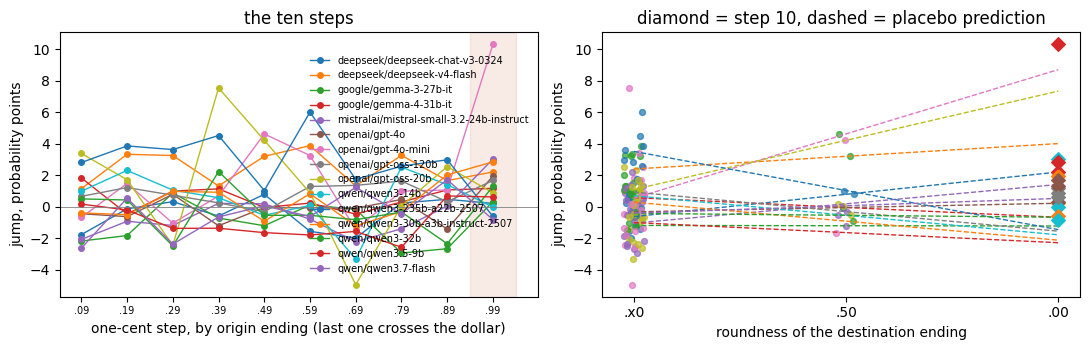

In [89]:
if PANEL is not None and "E1" in set(PANEL.experiment):
    import matplotlib.pyplot as plt
    d = prep(PANEL, "E1")
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for mid, g in d.groupby("model", sort=False):
        st = steps_from(ending_effects(g))
        axes[0].plot(st.step, st.jump, marker="o", ms=4, lw=1, label=mid)
        pl = st[st.step < 10]
        b, a = np.polyfit(pl.dest_round, pl.jump, 1)
        axes[1].scatter(pl.dest_round + np.random.uniform(-.05, .05, len(pl)), pl.jump, s=18, alpha=.7)
        xs = np.linspace(1, 3, 20)
        axes[1].plot(xs, a + b * xs, lw=1, ls="--")
        axes[1].scatter([3], st.loc[st.step == 10, "jump"], marker="D", s=48, zorder=5)
    axes[0].axvspan(9.5, 10.5, color="#c2410c", alpha=.10)
    axes[0].axhline(0, color="grey", lw=.6)
    axes[0].set_xticks(range(1, 11))
    axes[0].set_xticklabels([".%02d" % (s * 10 - 1) for s in range(1, 11)], fontsize=7)
    axes[0].set(xlabel="one-cent step, by origin ending (last one crosses the dollar)",
                ylabel="jump, probability points", title="the ten steps")
    axes[0].legend(fontsize=7, frameon=False)
    axes[1].set(xlabel="roundness of the destination ending",
                ylabel="jump, probability points",
                title="diamond = step 10, dashed = placebo prediction")
    axes[1].set_xticks([1, 2, 3]); axes[1].set_xticklabels([".x0", ".50", ".00"])
    plt.tight_layout(); plt.show()
